In [1]:
import getdist
from getdist import plots, MCSamples
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import sys


import cloudpickle as pickle

#from go_figure import go_figure
sys.path.append("/Users/lucas/repositories/des-hybrid/results/")

# plt.style.use('~/repositories/go_figure/ClassicScience.mplstyle')

plt.rcParams.update({
    "font.family": "serif",
    "text.usetex": True})

# plt.style.use('~/repositories/go_figure/ClassicScience.mplstyle')

# plt.rcParams.update({
#     #"font.family"       : "serif",
#     #"text.usetex"       : True,

#     # No minor ticks => half as many tick marks immediately
#     "xtick.minor.visible": False,
#     "ytick.minor.visible": False,

#     # … optional cosmetics
#     "xtick.major.size"  : 4,     # length  of the remaining ticks
#     "ytick.major.size"  : 4,
#     "xtick.major.width" : 0.9,   # thickness of the ticks
#     "ytick.major.width" : 0.9,
# })


%cd /Users/lucas/repositories/des-hybrid/

/Users/lucas/repositories/des-hybrid


/Users/lucas/venvs/ltu-ili/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


## Load Niall chain

Betti + 2nd moments, from 5 samples combined:

In [7]:
niall = np.load("./results/cl_cnn_samples_publication_version_niall.npy").squeeze()
burnin_niall = 0
niall.shape

(42000, 6, 3)

## Load chain from Marco (https://arxiv.org/pdf/2405.10881)

In [8]:
with open('./results/wcdm_judit.npy', 'rb') as f:
    marco = np.load(f, allow_pickle=True).item()

In [5]:
marco

{'Om': array([0.29452273, 0.28370119, 0.28410685, ..., 0.28635214, 0.31591086,
        0.28082789]),
 'S8': array([0.83241483, 0.8223595 , 0.80117609, ..., 0.78392934, 0.80400214,
        0.80439567]),
 'sigma_8': array([0.84011943, 0.84565216, 0.82328036, ..., 0.80239336, 0.78349378,
        0.83140041]),
 'w': array([-0.73524157, -0.61777033, -0.89520948, ..., -0.81270384,
        -0.70951629, -0.97009398]),
 'A': array([ 0.38590467,  0.40493612, -0.03481375, ...,  0.36772996,
         0.5085591 ,  0.21620194])}

## load hybrid chain

In [9]:
hybrid = np.load("./results/desy3_hybrid_unblinding_6chains_20_11_25.npy")
hybrid.shape

(6, 40000, 3)

In [10]:
hybrid.reshape(-1, 3).mean(0)

array([ 0.32565647,  0.8017902 , -0.8444843 ], dtype=float32)

In [11]:
burnin_niall = 0

In [12]:
np.c_[[4,5]]

array([[4],
       [5]])

## Plot comparison

Removed no burn in


Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
10344.828728834755
16020.741759839526
18702.230799064913
29618.4723275258
improvment over DES lensing:  2.8631186754178417
improvment over Judit:  1.8487578647433662
improvment over Niall:  1.5836866011196207


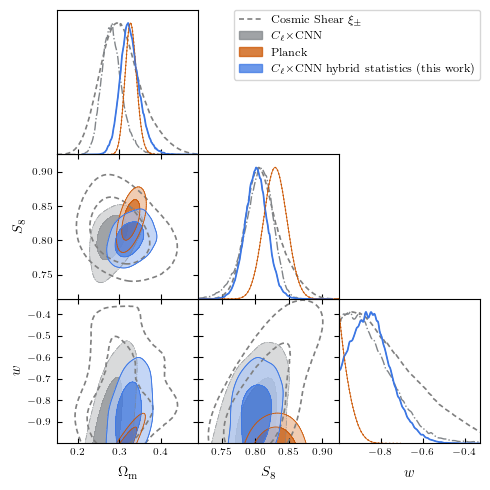

In [19]:

colors = [ 'gray', 
         "#818589",
        "#cc5500", # burnt orange
           "#3c77e4",
         ]


prior_om = [0.15, 0.49]
prior_s8 = [0.5, 1.]
prior_w = [-1, -0.33]
prior_IA = [-3, 3.]

n_burn2d = 0

chain_cosmic_shear = './results/desy3_shear_wcdmnu_hyperrank_noSR_2.txt'
uu = np.genfromtxt(chain_cosmic_shear, names=True)
mask = uu['cosmological_parametersomega_m'] > 0.1

label_marco = '2nd+3rd mom.+ST+WPH'
label_betti = r'2nd mom.+Betti'
label_cs = r'Cosmic Shear $\xi_{\pm}$'

# Plot settings
param_limits_plot = {
        'Om': (0.15, 0.49),
        's8': (0.715, 0.925),
        #'s8': (0.5, 1.2),
        'w': (-1, -0.33),
        'IA': (-2, 2)
    }



def reweight(p, mu, sigma):
    likelihood_gaussian = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((p - mu) / sigma)**2)
    likelihood_flat = 1.0  # Flat prior
    weight = likelihood_gaussian / likelihood_flat
    return weight

w1 = reweight(uu['cosmological_parametersh0'], 0.7022, 0.0245)
#w2 = reweight(uu['cosmological_parametersomega_b'], 0.9649, 0.0063)  
w2 = reweight(uu['cosmological_parametersn_s'], 0.9649, 0.0063)  
w3 = reweight((uu['cosmological_parametersomega_b'])*uu['cosmological_parametersh0']**2, 0.02237, 0.00015)  
#w3 = reweight(uu['cosmological_parametersomega_b'], 0.04553, 0.00320)  

names = ['Om', 's8', 'w']
labels = [r'\Omega_{\rm m}', 'S_8', 'w']
ranges = {'Om': prior_om, 's8': prior_s8, 'w': prior_w}

burnin = 1500

cs = MCSamples(samples=np.c_[uu['cosmological_parametersomega_m'][mask],
                            (uu['COSMOLOGICAL_PARAMETERSSIGMA_8']*np.sqrt(uu['cosmological_parametersomega_m']/0.3))[mask],
                            uu['cosmological_parametersw'][mask]][burnin:, ...],
               labels =labels,
               label=label_cs,
               weights=((uu['weight']*w1*w2*w3)[mask])[burnin:, ...], 
               ranges=ranges,
               names=names)


# LOAD PLANCK

planck = './results/DIRAC-planck-wcdm.txt'
uu = np.genfromtxt(planck, names=True)
mask = uu['cosmological_parametersomega_m'] > 0.1

# Plot settings
param_limits_plot = {
        'Om': (0.15, 0.49),
        's8': (0.715, 0.925),
        #'s8': (0.5, 1.2),
        'w': (-1, -0.33),
        'IA': (-2, 2)
    }

w1 = reweight(uu['cosmological_parametersh0'], 0.7022, 0.0245)
#w2 = reweight(uu['cosmological_parametersomega_b'], 0.9649, 0.0063)  
w2 = reweight(uu['cosmological_parametersn_s'], 0.9649, 0.0063)  
w3 = reweight((uu['cosmological_parametersomega_b'])*uu['cosmological_parametersh0']**2, 0.02237, 0.00015)  
#w3 = reweight(uu['cosmological_parametersomega_b'], 0.04553, 0.00320)  

names = ['Om', 's8', 'w']
labels = [r'\Omega_{\rm m}', 'S_8', 'w']
ranges = {'Om': prior_om, 's8': prior_s8, 'w': prior_w}

planck = MCSamples(samples=np.c_[uu['cosmological_parametersomega_m'][mask],
                            (uu['cosmological_parameterssigma_8_input']*np.sqrt(uu['cosmological_parametersomega_m']/0.3))[mask],
                            uu['cosmological_parametersw'][mask]][burnin:, ],
               labels =labels,
               label="Planck",
               weights=((uu['weight']*w1*w2*w3)[mask][burnin:]), 
               ranges=ranges,
               names=names)

planck_dummy = MCSamples(samples=np.c_[uu['cosmological_parametersomega_m'][mask],
                            (uu['cosmological_parameterssigma_8_input']*np.sqrt(uu['cosmological_parametersomega_m']/0.3))[mask],
                            uu['cosmological_parametersw'][mask]][burnin:, ],
               labels =labels,
               label="_nolegend_",
               weights=((uu['weight']*w1*w2*w3)[mask][burnin:]), 
               ranges=ranges,
               names=names)

samples_marco = MCSamples(samples=[marco['Om'], marco['S8'], marco['w']],
                    names=names,
                    labels=labels,
                    label=label_marco,
                    settings={'mult_bias_correction_order': 1,
                              'smooth_scale_2D': 0.4,
                              'smooth_scale_1D': 0.2},
                    ranges=ranges)


samples_niall = MCSamples(samples=[niall[:, burnin_niall:,0].flatten(),
                                   niall[:, burnin_niall:,1].flatten(), 
                                   niall[:, burnin_niall:,2].flatten(), 
                                  ],
                     names=['Om', 's8','w'],
                     labels=labels,
                    label=r'$C_\ell\times$CNN',
                    settings={'mult_bias_correction_order': 1,
                             'smooth_scale_2D': 0.4,
                             'smooth_scale_1D': 0.05},
                    ranges=ranges)


samples_niall_dummy = MCSamples(samples=[niall[:, burnin_niall:,0].flatten(),
                                   niall[:, burnin_niall:,1].flatten(), 
                                   niall[:, burnin_niall:,2].flatten(), 
                                  ],
                     names=['Om', 's8','w'],
                     labels=labels,
                    label=" ",
                    settings={'mult_bias_correction_order': 1,
                             'smooth_scale_2D': 0.4,
                             'smooth_scale_1D': 0.2},
                    ranges=ranges)

samples_hybrid = MCSamples(samples=[hybrid[burnin_niall:,:,0].flatten(),
                                    hybrid[burnin_niall:,:,1].flatten(), 
                                    hybrid[burnin_niall:,:,2].flatten()],
                     names=['Om', 's8','w'],
                     labels=labels,
                    label=r'$C_\ell \times $CNN hybrid statistics (this work)',
                    settings={'mult_bias_correction_order': 1,
                              'smooth_scale_2D': 0.4,
                              'smooth_scale_1D': 0.05},
                    ranges=ranges)


samples_hybrid_dummy = MCSamples(samples=[hybrid[burnin_niall:,:,0].flatten(),
                                    hybrid[burnin_niall:,:,1].flatten(), 
                                    hybrid[burnin_niall:,:,2].flatten()],
                     names=['Om', 's8','w'],
                     labels=labels,
                    label="_nolegend_",
                    settings={'mult_bias_correction_order': 1,
                              'smooth_scale_2D': 0.4,
                              'smooth_scale_1D': 0.05},
                    ranges=ranges)

# Configure plot aesthetics
g = plots.get_subplot_plotter(width_inch=5)


# Print figure of merit 
print(1./np.sqrt(np.linalg.det(cs.cov())))
# print(1./np.sqrt(np.linalg.det(samples_betti.cov())))
print(1./np.sqrt(np.linalg.det(samples_marco.cov())))
print(1./np.sqrt(np.linalg.det(samples_niall.cov())))

print(1./np.sqrt(np.linalg.det(samples_hybrid.cov())))
      

print("improvment over DES lensing: ", \
      (1./np.sqrt(np.linalg.det(samples_hybrid.cov()))) / (1./np.sqrt(np.linalg.det(cs.cov())))
     )

print("improvment over Judit: ", \
      (1./np.sqrt(np.linalg.det(samples_hybrid.cov()))) / (1./np.sqrt(np.linalg.det(samples_marco.cov())))
     )

print("improvment over Niall: ", \
      (1./np.sqrt(np.linalg.det(samples_hybrid.cov()))) / (1./np.sqrt(np.linalg.det(samples_niall.cov())))
     )

g.settings.alpha_filled_add = 0.75
g.settings.alpha_factor_contour_lines = 0.9
g.settings.norm_1d_density = False

# Plot the triangle plot with customized settings
g.triangle_plot([cs, 
                 samples_niall, 
                 planck,
                 samples_hybrid, 
                 planck_dummy,
                 samples_hybrid_dummy
                ], ['Om', 's8', 'w'], 
                legend_loc='upper right',legend_title='DES Y3', 
                filled=[False, True, True, True, False, False],
                contour_ls = ['--','dashdot', ':', '-','-', ],  
                contour_lws=[1.2,1,1,1.25],
                contour_colors= colors + [colors[2], colors[3]], param_limits=param_limits_plot,
                title_limit=None, diag1d_kwargs=dict(normalized=False))



        
# Save the figure
# plt.savefig('./paper/plots/' + 'DESY3_hybrid_w.png', dpi=500)
# plt.savefig('./paper/plots/' + 'DESY3_hybrid_w.pdf', dpi=500)



Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
10344.82872656468
16020.741759839526
18702.230799064913
29618.4723275258
improvment over DES lensing:  2.8631186760461262
improvment over Marco:  1.8487578647433662
improvment over Niall:  1.5836866011196207


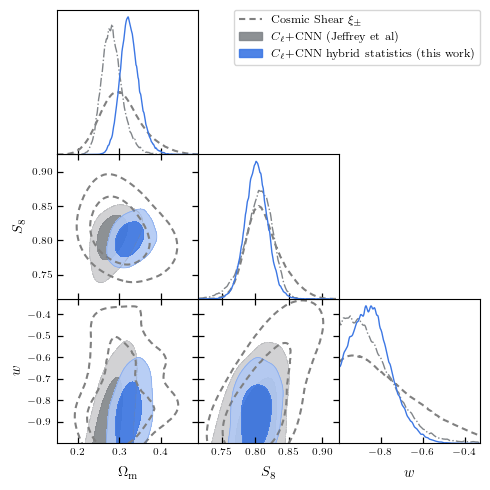

In [126]:
#colors = ['#003F5C', '#BC5090', '#FF6361', '#FFA600']
# colors = [ '#3c77e4', '#9D3B6C','#FFA600' , '#19123C', '#3c77e4']

colors = [ 'gray', 
          # '#36454F' , 
          "#818589",
          # '#183e41',
           '#377863',
          # 'k' , 
          # '#3c77e4',
          '#19123C', '#3c77e4']


colors = [ 'gray', 
          "#818589",
           "#3c77e4",
          # '#183e41',
          # '#377863',
          # 'k' , 
          # '#3c77e4',
          '#19123C', '#3c77e4']


prior_om = [0.15, 0.49]
prior_s8 = [0.5, 1.]
prior_w = [-1, -0.33]
prior_IA = [-3, 3.]

n_burn2d = 0

chain_cosmic_shear = './results/desy3_shear_wcdmnu_hyperrank_noSR_2.txt'
uu = np.genfromtxt(chain_cosmic_shear, names=True)
mask = uu['cosmological_parametersomega_m'] > 0.1

label_marco = '2nd+3rd mom.+ST+WPH'
label_betti = r'2nd mom.+Betti'
label_cs = r'Cosmic Shear $\xi_{\pm}$'

# Plot settings
param_limits_plot = {
        'Om': (0.15, 0.49),
        's8': (0.715, 0.925),
        #'s8': (0.5, 1.2),
        'w': (-1, -0.33),
        'IA': (-2, 2)
    }



def reweight(p, mu, sigma):
    likelihood_gaussian = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((p - mu) / sigma)**2)
    likelihood_flat = 1.0  # Flat prior
    weight = likelihood_gaussian / likelihood_flat
    return weight

w1 = reweight(uu['cosmological_parametersh0'], 0.7022, 0.0245)
#w2 = reweight(uu['cosmological_parametersomega_b'], 0.9649, 0.0063)  
w2 = reweight(uu['cosmological_parametersn_s'], 0.9649, 0.0063)  
w3 = reweight((uu['cosmological_parametersomega_b'])*uu['cosmological_parametersh0']**2, 0.02237, 0.00015)  
#w3 = reweight(uu['cosmological_parametersomega_b'], 0.04553, 0.00320)  

names = ['Om', 's8', 'w']
labels = [r'\Omega_{\rm m}', 'S_8', 'w']
ranges = {'Om': prior_om, 's8': prior_s8, 'w': prior_w}

cs = MCSamples(samples=np.c_[uu['cosmological_parametersomega_m'][mask],
                            (uu['COSMOLOGICAL_PARAMETERSSIGMA_8']*np.sqrt(uu['cosmological_parametersomega_m']/0.3))[mask],
                            uu['cosmological_parametersw'][mask]],
               labels =labels,
               label=label_cs,
               weights=((uu['weight']*w1*w2*w3)[mask]), 
               ranges=ranges,
               names=names)


samples_marco = MCSamples(samples=[marco['Om'], marco['S8'], marco['w']],
                    names=names,
                    labels=labels,
                    label=label_marco,
                    settings={'mult_bias_correction_order': 1,
                              'smooth_scale_2D': 0.4,
                              'smooth_scale_1D': 0.2},
                    ranges=ranges)


samples_niall = MCSamples(samples=[niall[:, burnin_niall:,0].flatten(),
                                   niall[:, burnin_niall:,1].flatten(), 
                                   niall[:, burnin_niall:,2].flatten(), 
                                  ],
                     names=['Om', 's8','w'],
                     labels=labels,
                    label='$C_\ell+$CNN (Jeffrey et al)',
                    settings={'mult_bias_correction_order': 1,
                             'smooth_scale_2D': 0.4,
                             'smooth_scale_1D': 0.05},
                    ranges=ranges)


samples_niall_dummy = MCSamples(samples=[niall[:, burnin_niall:,0].flatten(),
                                   niall[:, burnin_niall:,1].flatten(), 
                                   niall[:, burnin_niall:,2].flatten(), 
                                  ],
                     names=['Om', 's8','w'],
                     labels=labels,
                    label=" ",
                    settings={'mult_bias_correction_order': 1,
                             'smooth_scale_2D': 0.4,
                             'smooth_scale_1D': 0.2},
                    ranges=ranges)

samples_hybrid = MCSamples(samples=[hybrid[burnin_niall:,:,0].flatten(),
                                    hybrid[burnin_niall:,:,1].flatten(), 
                                    hybrid[burnin_niall:,:,2].flatten()],
                     names=['Om', 's8','w'],
                     labels=labels,
                    label='$C_\ell+$CNN hybrid statistics (this work)',
                    settings={'mult_bias_correction_order': 1,
                              'smooth_scale_2D': 0.4,
                              'smooth_scale_1D': 0.05},
                    ranges=ranges)




# Configure plot aesthetics
g = plots.get_subplot_plotter(width_inch=5)


# Print figure of merit 
print(1./np.sqrt(np.linalg.det(cs.cov())))
# print(1./np.sqrt(np.linalg.det(samples_betti.cov())))
print(1./np.sqrt(np.linalg.det(samples_marco.cov())))
print(1./np.sqrt(np.linalg.det(samples_niall.cov())))

print(1./np.sqrt(np.linalg.det(samples_hybrid.cov())))
      

print("improvment over DES lensing: ", \
      (1./np.sqrt(np.linalg.det(samples_hybrid.cov()))) / (1./np.sqrt(np.linalg.det(cs.cov())))
     )

print("improvment over Marco: ", \
      (1./np.sqrt(np.linalg.det(samples_hybrid.cov()))) / (1./np.sqrt(np.linalg.det(samples_marco.cov())))
     )

print("improvment over Niall: ", \
      (1./np.sqrt(np.linalg.det(samples_hybrid.cov()))) / (1./np.sqrt(np.linalg.det(samples_niall.cov())))
     )

g.settings.alpha_filled_add = 0.9
g.settings.alpha_factor_contour_lines = 0.4

# Plot the triangle plot with customized settings
g.triangle_plot([cs, samples_niall, samples_hybrid], ['Om', 's8', 'w'], 
                legend_loc='upper right',legend_title='DES Y3', 
                filled=[False, True, True, False, False],
                contour_ls = ['--','dashdot', '-', 'dashdot','-'],  
                contour_lws=[1.5,1,1,1],
                contour_colors= colors, param_limits=param_limits_plot,
                title_limit=None, diag1d_kwargs=dict(normalized=True))



        
# Save the figure
plt.savefig('./paper/plots/' + 'DESY3_hybrid_w.png', dpi=500)
plt.savefig('./paper/plots/' + 'DESY3_hybrid_w.pdf', dpi=500)


In [361]:

print("improvment over DES lensing: ", \
      (1./np.sqrt(np.linalg.det(samples_hybrid.cov()))) / (1./np.sqrt(np.linalg.det(cs.cov())))
     )

print("improvment over Marco: ", \
      (1./np.sqrt(np.linalg.det(samples_hybrid.cov()))) / (1./np.sqrt(np.linalg.det(samples_marco.cov())))
     )

print("improvment over Niall: ", \
      (1./np.sqrt(np.linalg.det(samples_hybrid.cov()))) / (1./np.sqrt(np.linalg.det(samples_niall.cov())))
     )

improvment over DES lensing:  2.8631186754178417
improvment over Marco:  1.8487578647433662
improvment over Niall:  1.5836866011196207


In [165]:
samples_hybrid.cov(pars=pars).shape

(2, 2)

In [358]:
samples_hybrid.

AttributeError: 'MCSamples' object has no attribute 'MAP'

In [328]:
pars = [0,1]


print("improvment over DES lensing for pars: ", pars, \
      (1./np.sqrt(np.linalg.det(samples_hybrid.cov(pars)))) / (1./np.sqrt(np.linalg.det(cs.cov(pars))))
     )

print("improvment over Marco for pars: ", pars, \
      (1./np.sqrt(np.linalg.det(samples_hybrid.cov(pars)))) / (1./np.sqrt(np.linalg.det(samples_marco.cov(pars))))
     )

print("improvment over Niall for pars: ", pars, \
      (1./np.sqrt(np.linalg.det(samples_hybrid.cov(pars)))) / (1./np.sqrt(np.linalg.det(samples_niall.cov(pars))))
     )

print("our FoM for pars: ", pars, \
      (1./np.sqrt(np.linalg.det(samples_hybrid.cov(pars)))) 
     )

improvment over DES lensing for pars:  [0, 1] 2.8922527221041587
improvment over Marco for pars:  [0, 1] 1.5096270160638927
improvment over Niall for pars:  [0, 1] 1.3664884088711144
our FoM for pars:  [0, 1] 2604.493631084514


In [356]:
(1./np.sqrt(np.linalg.det(cs.cov([0,1,2]))))

10344.828728834755

In [319]:
print(1./np.sqrt(np.linalg.det(samples_hybrid.cov()))), print(1./np.sqrt(np.linalg.det(samples_niall.cov())))

29618.4723275258
18702.230799064913


(None, None)

In [167]:
pars = [0,2]


print("improvment over DES lensing for pars: ", pars, \
      (1./np.sqrt(np.linalg.det(samples_hybrid.cov(pars)))) / (1./np.sqrt(np.linalg.det(cs.cov(pars))))
     )

print("improvment over Marco for pars: ", pars, \
      (1./np.sqrt(np.linalg.det(samples_hybrid.cov(pars)))) / (1./np.sqrt(np.linalg.det(samples_marco.cov(pars))))
     )

print("improvment over Niall for pars: ", pars, \
      (1./np.sqrt(np.linalg.det(samples_hybrid.cov(pars)))) / (1./np.sqrt(np.linalg.det(samples_niall.cov(pars))))
     )

improvment over DES lensing for pars:  [0, 2] 3.4546828698171455
improvment over Marco for pars:  [0, 2] 1.6522555967296169
improvment over Niall for pars:  [0, 2] 1.2296242738239376


In [114]:
getdist.types.ResultTable(3, [cs, samples_niall, samples_hybrid], limit=1).tableTex()

'\\begin{tabular} { l  c c c| l  c c c| l  c c c}\n\n Parameter &  68\\% limits &  68\\% limits &  68\\% limits &  Parameter &  68\\% limits &  68\\% limits &  68\\% limits &  Parameter &  68\\% limits &  68\\% limits &  68\\% limits\\\\\n\\hline\n{\\boldmath$\\Omega_{\\rm m} $} & $0.303^{+0.040}_{-0.051}   $ & $0.283^{+0.020}_{-0.027}   $ & $0.326^{+0.020}_{-0.026}   $ & {\\boldmath$S_8            $} & $0.813^{+0.020}_{-0.029}   $ & $0.804^{+0.025}_{-0.017}   $ & $0.802\\pm 0.017            $ & {\\boldmath$w              $} & $< -0.707                  $ & $< -0.804                  $ & $-0.844^{+0.065}_{-0.12}   $\\\\\n\\hline\n\\end{tabular}'

In [108]:
print('des 2pt', cs.getLatex())
print('niall', samples_niall.getLatex())
print('hybrid', samples_hybrid.getLatex())

des 2pt (['\\Omega_{\\rm m}', 'S_8', 'w'], ['0.303^{+0.040}_{-0.051}', '0.813^{+0.020}_{-0.029}', '< -0.707'])
niall (['\\Omega_{\\rm m}', 'S_8', 'w'], ['0.283^{+0.020}_{-0.027}', '0.804^{+0.025}_{-0.017}', '< -0.804'])
hybrid (['\\Omega_{\\rm m}', 'S_8', 'w'], ['0.326^{+0.020}_{-0.026}', '0.802\\pm 0.017', '-0.844^{+0.065}_{-0.12}'])


In [121]:
for i in range(3):
    print('$' + (cs.getLatex()[1][i]) + '$')
    print('$' + samples_niall.getLatex()[1][i] + '$' )
    print('$' + samples_hybrid.getLatex()[1][i] + '$')

$0.303^{+0.040}_{-0.051}$
$0.283^{+0.020}_{-0.027}$
$0.326^{+0.020}_{-0.026}$
$0.813^{+0.020}_{-0.029}$
$0.804^{+0.025}_{-0.017}$
$0.802\pm 0.017$
$< -0.707$
$< -0.804$
$-0.844^{+0.065}_{-0.12}$


## posterior predictive tests in Cls

In [561]:
# read in full summary cloud and prune Cls file


import torch
def scale_params(theta):
    hi = np.array([0.5, 1.0, -0.33])
    lo = np.array([0.13, 0.0, -1.8])
    theta_ = theta.copy()
    s = 0.6
    theta_[:, 0] = (theta[:, 0] - lo[0])*s / (hi[0] - lo[0]) + (1 - s)*0.5
    theta_[:, 1] -= 0.25
    theta_[:, 2] =  (theta[:, 2] - lo[2])*s / (hi[2] - lo[2]) + (1 - s)*0.5
    
    return theta_

def inv_scale_params(theta):
    hi = np.array([0.5, 1.0, -0.33])
    lo = np.array([0.13, 0.0, -1.8])
    theta_ = theta.copy()
    s = 0.6
    theta_[:, 0] = ((theta[:, 0] - (1 - s)*0.5) * (hi[0] - lo[0]) / s) + lo[0]
    theta_[:, 1] += 0.25
    theta_[:, 2] =  ((theta[:, 2] - (1 - s)*0.5) * (hi[2] - lo[2]) / s) + lo[2]

    return theta_

def save_obj(obj, name ):
    with open(name + '.pkl', 'wb') as f:
        pickle.dump(obj, f)

def load_obj(name):
    with open(name, 'rb') as f:
        return pickle.load(f)


low=[0.15, 0.5, -1.78]; 
high=[0.52, 1.0, -0.3333]

def mask_prior_and_summaries(theta, summs, low=torch.tensor(low), high=torch.tensor(high)):
    condition = (~torch.any(theta.lt(low), keepdim=True, dim=-1)) & (~torch.any(theta.gt(high), keepdim=True, dim=-1))
    mask = condition.squeeze()
    return theta.float()[mask], summs.float()[mask], mask


file = load_obj("./density_estimation/local_testing/final-summaries-unblinding.pkl")[-1]

preds_val = file["summs_test"]
params_val = file["params_test"]

params_LFI = (file['params_lfi'])
preds_LFI = file['summs_lfi']

params_test = (file['params_sys'])
preds_test = file['summs_sys']

preds_train = file["summs_train"]
params_train = file["params_train"]

low_theta=[0.15, 0.5, -1.1];  ## CUTTING AT w=-1.1
high_theta=[0.52, 1.0, -0.3333]


low_theta=[0.15, 0.5, -1.05];  ## CUTTING AT w=-1.05
high_theta=[0.52, 1.0, -0.3333]


# low_theta=[0.2, 0.6, -1.0];  ## CUTTING AT w=-1.05
# high_theta=[0.45, 0.9, -0.3333]

# step 1: mask the prior from the test set in scaled_params space
hi_scaled = scale_params(np.array([high_theta]))
lo_scaled = scale_params(np.array([low_theta]))


# pull in matched Cls file

clsfile = np.load("./results/cls_for_posterior_preds_2.npz")

cls_target = clsfile["cls_target"]
all_cls_test = clsfile["cls_test"]

params_test_ = clsfile["theta_test"]

ndefilepath = "/Users/lucas/repositories/des-hybrid/density_estimation/local_testing/final_nde_19_11/"

print((params_test_ != params_test).sum())


params_test, preds_test, mask = mask_prior_and_summaries(torch.tensor(params_test), 
                               torch.tensor(preds_test),
                               low=torch.tensor(lo_scaled), 
                               high=torch.tensor(hi_scaled))

# _, all_cls_test, _ = mask_prior_and_summaries(torch.tensor(params_test_), 
#                                torch.tensor(all_cls_test.reshape(all_cls_test.shape[0], -1)),
#                                low=torch.tensor(lo_scaled), 
#                                high=torch.tensor(hi_scaled))

all_cls_test = all_cls_test[mask]

# all_cls_test = all_cls_test.reshape((params_test.shape[0],) + cls_target.shape)

CUT = 28 # keep all

print("CLS SHAPE: ", all_cls_test.shape)

# CLS SHAPE: [:, real/randoms, (EE,EB,BE,BB), :CUT]

all_cls_test = all_cls_test[:, :, 0, 0, :CUT] - all_cls_test[:, :, 1, 0, :CUT]
# all_cls_test = np.clip(all_cls_test, a_min=0.0, a_max=np.inf)

cls_target = cls_target[:, 0, 0, :CUT] -  cls_target[:, 1, 0, :CUT]




# ellvals = np.array([ 12.5,  23.5,  37.5,  55. ,  75.5,  99.5, 127.5, 158.5, 192.5,
#        230.5, 271.5, 316. , 364. , 415. , 469.5, 527.5, 589. , 653.5,
#        721.5, 793. , 868. , 946. ]) # up to scale cut


ellvals = np.array([12.5, 23.5, 37.5, 55.0, 75.5, 99.5, 127.5, 158.5, 192.5, 230.5, 271.5, 316.0, 
       364.0, 415.0, 469.5, 527.5, 589.0, 653.5, 721.5, 793.0, 868.0, 946.0, 
       1027.5, 1112.5, 1200.5, 1292.5, 1387.5, 1485.5])[:CUT]


# cls_target *= ellvals[np.newaxis, :]
# all_cls_test *= ellvals[np.newaxis, np.newaxis, :]

        
# hybrid (['\\Omega_{\\rm m}', 'S_8', 'w'], ['0.326^{+0.020}_{-0.026}', '0.802\\pm 0.017', '-0.844^{+0.065}_{-0.12}'])
# fix at posterior mean
theta_post_mean = scale_params(np.ones((preds_test.shape[0], 3)) * np.array([0.326, 0.802, -0.844]))

# load nde from file
# like_ensemble = load_obj(ndefilepath + "posterior.pkl")



cl_index = {"1_1": 0,
            "1_2": 1,
            "1_3": 2,
            "1_4": 3,
            "2_2": 4,
            "2_3": 5,
            "2_4": 6,
            "3_3": 7,
            "3_4": 8,
            "4_4": 9,
}

0
CLS SHAPE:  (2828, 10, 2, 4, 28)


In [432]:
cls_target.shape

(10, 28)

In [383]:
cl_index["1_1"]

0

In [372]:
all_cls_test.min()

-8.707521e-08

In [373]:
params_test, params_test_

(tensor([[0.4595, 0.5029, 0.5229],
         [0.4595, 0.5029, 0.5229],
         [0.4595, 0.5029, 0.5229],
         ...,
         [0.4622, 0.5494, 0.6984],
         [0.4622, 0.5494, 0.6984],
         [0.4622, 0.5494, 0.6984]]),
 array([[0.45952517, 0.50293326, 0.522881  ],
        [0.45952517, 0.50293326, 0.522881  ],
        [0.45952517, 0.50293326, 0.522881  ],
        ...,
        [0.46221   , 0.5493731 , 0.69837767],
        [0.46221   , 0.5493731 , 0.69837767],
        [0.46221   , 0.5493731 , 0.69837767]], dtype=float32))

In [374]:
cls_target.shape

(10, 28)

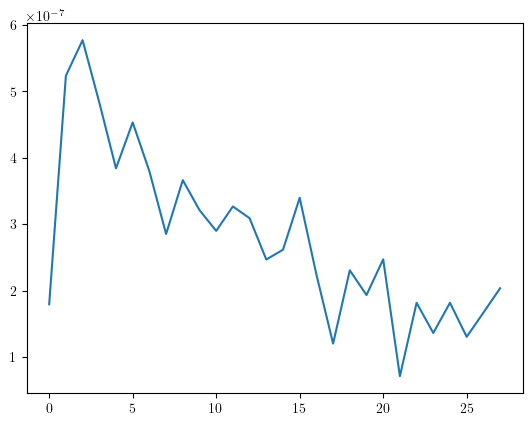

In [516]:
plt.plot(cls_target[cl_index["3_4"], ...].flatten())

In [376]:
like_ensemble.log_prob(torch.tensor(theta_post_mean, dtype=torch.float)[:5], torch.tensor(preds_test, dtype=torch.float)[:5])

/var/folders/pg/xm7nmkzn0tq26tlbl6skh5080000gp/T/ipykernel_71529/4275826843.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  like_ensemble.log_prob(torch.tensor(theta_post_mean, dtype=torch.float)[:5], torch.tensor(preds_test, dtype=torch.float)[:5])
/Users/lucas/venvs/ltu-ili/lib/python3.10/site-packages/sbi/inference/posteriors/mcmc_posterior.py:172: UserWarning: `.log_prob()` is deprecated for methods that can only evaluate the
            log-probability up to a normalizing constant. Use `.potential()` instead.
  warn(
/Users/lucas/venvs/ltu-ili/lib/python3.10/site-packages/sbi/inference/posteriors/mcmc_posterior.py:176: UserWarning: The log-probability is unnormalized!
  warn("The log-probability is unnormalized!")
/Users/lucas/venvs/ltu-ili/lib/python3.10/site-packages/sbi/utils/sbiutils.py:316: UserWarning: An x with a batch s

tensor([-1038.9207, -1038.9207, -1038.9207, -1038.9207, -1038.9208])

In [408]:
import scipy


# assign log-probs to the test summaries
log_probs_test_post = np.array([like_ensemble.potential(torch.tensor(theta_post_mean, dtype=torch.float)[i], torch.tensor(preds_test, dtype=torch.float)[i]).numpy()
                      for i in range(theta_post_mean.shape[0])]).squeeze()

# log_probs_test_post -= log_probs_test_post.min()

log_probs_test_post = scipy.special.softmax(log_probs_test_post)

/var/folders/pg/xm7nmkzn0tq26tlbl6skh5080000gp/T/ipykernel_71529/1779729720.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  log_probs_test_post = np.array([like_ensemble.potential(torch.tensor(theta_post_mean, dtype=torch.float)[i], torch.tensor(preds_test, dtype=torch.float)[i]).numpy()


(array([2.819e+03, 2.000e+00, 3.000e+00, 1.000e+00, 0.000e+00, 1.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 2.000e+00]),
 array([0.        , 0.02231438, 0.04462877, 0.06694315, 0.08925754,
        0.11157192, 0.13388631, 0.15620069, 0.17851508, 0.20082946,
        0.22314385]),
 <BarContainer object of 10 artists>)

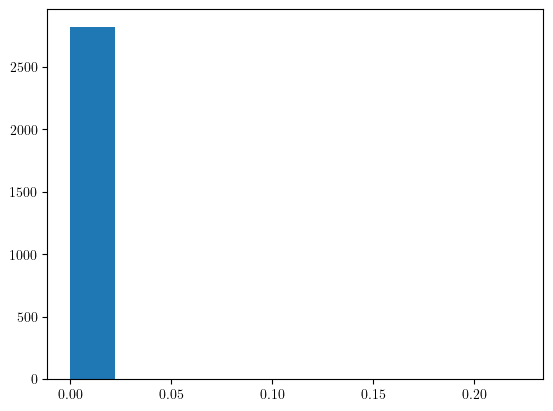

In [409]:
plt.hist(((log_probs_test_post - log_probs_test_post.min())))

In [410]:
log_probs_test_post

array([4.3085925e-12, 4.0328005e-11, 3.0473343e-12, ..., 9.2491277e-08,
       4.1912323e-08, 3.3485457e-09], dtype=float32)

In [518]:
cls_weighted_mean = np.average(all_cls_test, weights=np.exp(log_probs_test_post), axis=0)

cls_weighted_std = weighted_std((all_cls_test), w=np.exp(log_probs_test_post)[..., np.newaxis, np.newaxis], axis=0)


In [519]:
cls_weighted_mean.shape, all_cls_test.shape

((10, 28), (2828, 10, 28))

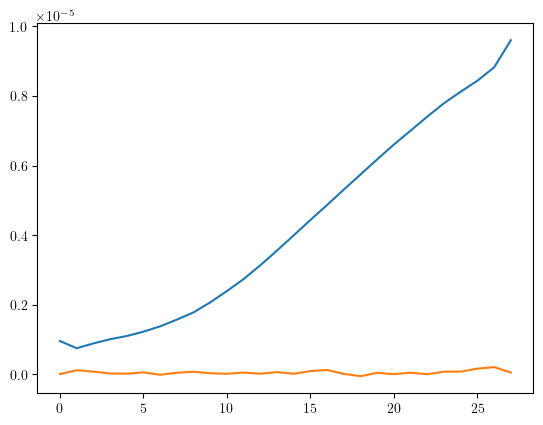

In [520]:


# for i in range(34):
#     plt.plot(all_cls_test[i, 0, ...], c='k', alpha=0.3)

             
plt.plot(cls_weighted_mean[0])
plt.plot(cls_target[0])

In [87]:
ellvals.shape, all_cls_test.shape

((22,), torch.Size([2828, 10, 2, 4, 22]))

In [551]:
np.tril_indices_from(np.ones((4,4)))

(array([0, 1, 1, 2, 2, 2, 3, 3, 3, 3]), array([0, 0, 1, 0, 1, 2, 0, 1, 2, 3]))

In [580]:
import numpy as np
import matplotlib.pyplot as plt


def weighted_std(x, w, *, axis=None, ddof=0, keepdims=False):
    """
    Compute the weighted standard deviation along a given axis.

    Parameters
    ----------
    x : array_like
        Data values
    w : array_like
        Weights (broadcastable to x)
    axis : int or tuple of ints, optional
        Axis or axes along which to compute the std
    ddof : int, optional
        Delta degrees of freedom
    keepdims : bool, optional
        Keep reduced dimensions

    Returns
    -------
    std : ndarray
        Weighted standard deviation
    """
    x = np.asarray(x)
    w = np.asarray(w)

    if np.any(w < 0):
        raise ValueError("Weights must be non-negative")

    wsum = np.sum(w, axis=axis, keepdims=True)
    if np.any(wsum == 0):
        raise ValueError("Sum of weights must be non-zero")

    # Weighted mean
    mean = np.sum(w * x, axis=axis, keepdims=True) / wsum

    # Weighted variance
    var = np.sum(w * (x - mean)**2, axis=axis, keepdims=True) / (wsum - ddof)

    std = np.sqrt(var)

    if not keepdims and axis is not None:
        std = np.squeeze(std, axis=axis)

    return std


import numpy as np
import matplotlib.pyplot as plt

def triangle_plot(
    x,
    y,
    y_ref=None,
    yerr=None,
    *,
    nbins=4,
    figsize=(12, 12),
    sharex=True,
    sharey=False,
    xscale="log",
    yscale="linear",
    xlabel=None,
    ylabel=None,
    res_ylabel=r"$\Delta$",
    titles=True,
    show_residuals=False,
    plot_kwargs=None,
    err_kwargs=None,
    res_kwargs=None,
    res_err_kwargs=None,
    cut_idx=None
):
    """
    Lower-triangle plot with optional residual panels.

    Residuals: (y / y_ref) - 1

    Parameters
    ----------
    x : array (npts,)
    y : array (nbins, npts)
    y_ref : array (nbins, npts), required if show_residuals=True
    yerr : array or None
        (nbins, npts) or (2, nbins, npts)
    show_residuals : bool
        Toggle residual panels
    """

    if plot_kwargs is None:
        plot_kwargs = {}
    if err_kwargs is None:
        err_kwargs = dict(alpha=0.3)
    if res_kwargs is None:
        res_kwargs = dict(marker="o", linestyle="None")
    if res_err_kwargs is None:
        res_err_kwargs = dict(alpha=0.3)

    if show_residuals and y_ref is None:
        raise ValueError("y_ref must be provided when show_residuals=True")

    # Figure layout
    if show_residuals:
        fig, axes = plt.subplots(
            2 * nbins, nbins,
            figsize=figsize,
            gridspec_kw={"height_ratios": [2, 1] * nbins},
            sharex="col",
        )
    else:
        fig, axes = plt.subplots(
            nbins, nbins,
            figsize=figsize,
            sharex=sharex,
            sharey=sharey,
        )

    plot_idx = np.tril_indices(nbins)

    for i in range(nbins):
        for j in range(nbins):

            if show_residuals:
                main_ax = axes[2 * j, i]
                res_ax  = axes[2 * j + 1, i]
            else:
                main_ax = axes[j, i]

            # Hide upper triangle
            if j < i:
                main_ax.set_visible(False)
                if show_residuals:
                    res_ax.set_visible(False)
                continue
                

            # ---------- main panel ----------
            main_ax.plot(x, y[plot_idx], **plot_kwargs)

            if yerr is not None:
                #if yerr.ndim == 2:
                ylo = y_ref[plot_idx] - yerr[plot_idx]
                yhi = y_ref[plot_idx] + yerr[plot_idx]
                #else:
                #    ylo = y[i] - yerr[0, i]
                #    yhi = y[i] + yerr[1, i]

                main_ax.fill_between(x, ylo, yhi, **err_kwargs)

            main_ax.set_xscale(xscale)
            main_ax.set_yscale(yscale)
            # main_ax.set_ylim(0, 2e-6)
            
            if cut_idx is not None:
                main_ax.axvline(x[cut_idx], c='k', ls=':')

            if titles:
                main_ax.set_title(f"Bin {i+1}")

            if i == 0 and ylabel is not None:
                main_ax.set_ylabel(ylabel)

            # ---------- residual panel ----------
            if show_residuals:
                res = (y_ref[i] / y[i]) - 1
                res_ax.plot(x, res, **res_kwargs)

                if yerr is not None:
                    #if yerr.ndim == 2:
                    res_err = (yerr[i]  / y[i]) - 1
                    #else:
                    #    res_err = 0.5 * (yerr[0, i] + yerr[1, i]) / y_ref[i]

                    res_ax.fill_between(
                        x,
                        res - res_err,
                        res + res_err,
                        **res_err_kwargs,
                    )

                res_ax.axhline(0, color="k", ls="--", lw=1)
                res_ax.set_xscale("log")
                res_ax.set_yscale("linear")
                if cut_idx is not None:
                    res_ax.axvline(x[cut_idx], c='k', ls=':')
                # res_ax.set_ylim(-10.0, 10.0)

                if i == 0:
                    res_ax.set_ylabel(res_ylabel)

                if j == nbins - 1 and xlabel is not None:
                    res_ax.set_xlabel(xlabel)
            else:
                if j == nbins - 1 and xlabel is not None:
                    main_ax.set_xlabel(xlabel)

    plt.tight_layout()
    return fig, axes





import numpy as np
import matplotlib.pyplot as plt


def weighted_std(x, w, *, axis=None, ddof=0, keepdims=False):
    """
    Compute the weighted standard deviation along a given axis.

    Parameters
    ----------
    x : array_like
        Data values
    w : array_like
        Weights (broadcastable to x)
    axis : int or tuple of ints, optional
        Axis or axes along which to compute the std
    ddof : int, optional
        Delta degrees of freedom
    keepdims : bool, optional
        Keep reduced dimensions

    Returns
    -------
    std : ndarray
        Weighted standard deviation
    """
    x = np.asarray(x)
    w = np.asarray(w)

    if np.any(w < 0):
        raise ValueError("Weights must be non-negative")

    wsum = np.sum(w, axis=axis, keepdims=True)
    if np.any(wsum == 0):
        raise ValueError("Sum of weights must be non-zero")

    # Weighted mean
    mean = np.sum(w * x, axis=axis, keepdims=True) / wsum

    # Weighted variance
    var = np.sum(w * (x - mean)**2, axis=axis, keepdims=True) / (wsum - ddof)

    std = np.sqrt(var)

    if not keepdims and axis is not None:
        std = np.squeeze(std, axis=axis)

    return std


import numpy as np
import matplotlib.pyplot as plt

import numpy as np
import matplotlib.pyplot as plt

def triangle_plot(
    x,
    y,
    y_ref=None,
    yerr=None,
    *,
    nbins=4,
    figsize=(12, 12),
    sharex=True,
    sharey=False,
    xscale="log",
    yscale="linear",
    xlabel=None,
    ylabel=None,
    res_ylabel=r"$\Delta$",
    titles=True,
    show_residuals=False,
    plot_kwargs=None,
    err_kwargs=None,
    res_kwargs=None,
    res_err_kwargs=None,
    cut_idx=None,
    fill=True
):
    """
    Lower-triangle plot with optional residual panels.

    Residuals: (y / y_ref) - 1

    Parameters
    ----------
    x : array (npts,)
    y : array (n_shapes, npts) where n_shapes = nbins*(nbins+1)/2
        Shape parameters in order: [(1,1), (2,1), (2,2), (3,1), (3,2), (3,3), ...]
    y_ref : array (n_shapes, npts), required if show_residuals=True
    yerr : array or None
        (n_shapes, npts) or (2, n_shapes, npts)
    show_residuals : bool
        Toggle residual panels
    """

    if plot_kwargs is None:
        plot_kwargs = {}
    if err_kwargs is None:
        err_kwargs = dict(alpha=0.3)
    if res_kwargs is None:
        res_kwargs = dict(marker="o", linestyle="None")
    if res_err_kwargs is None:
        res_err_kwargs = dict(alpha=0.3)

    if show_residuals and y_ref is None:
        raise ValueError("y_ref must be provided when show_residuals=True")

    # Figure layout
    if show_residuals:
        fig, axes = plt.subplots(
            2 * nbins, nbins,
            figsize=figsize,
            gridspec_kw={"height_ratios": [2, 1] * nbins},
            sharex="col",
        )
    else:
        fig, axes = plt.subplots(
            nbins, nbins,
            figsize=figsize,
            sharex=sharex,
            sharey=sharey,
        )

    shape_idx = 0
    for bini in range(nbins):
        for binj in range(bini, nbins):

            if show_residuals:
                main_ax = axes[2 * binj, bini]
                res_ax  = axes[2 * binj + 1, bini]
            else:
                main_ax = axes[binj, bini]

            # ---------- main panel ----------
            main_ax.scatter(x, y[shape_idx],marker="x", color='red', **plot_kwargs)
            main_ax.plot(x, y_ref[shape_idx],marker="o", color='blue', **plot_kwargs)

            if yerr is not None:
                #if yerr.ndim == 2:
                ylo = y_ref[shape_idx] - yerr[shape_idx]
                yhi = y_ref[shape_idx] + yerr[shape_idx]
                #else:
                #    ylo = y[shape_idx] - yerr[0, shape_idx]
                #    yhi = y[shape_idx] + yerr[1, shape_idx]

                if fill:
                    main_ax.fill_between(x, ylo, yhi, **err_kwargs)

            main_ax.set_xscale(xscale)
            main_ax.set_yscale(yscale)
            # main_ax.set_ylim(0, 5e-6) #./density_estimation/local_testing/final_dry_ABC_four_runs_all_7summs_newbary_10_11_relu_long.pkl
            
            main_ax.set_xlim(10, 2e3)
            
            if cut_idx is not None:
                print("cut")
                main_ax.axvline(x[cut_idx], c='k', ls=':')

            if titles:
                main_ax.set_title(f"({bini+1},{binj+1})")

            if bini == 0 and ylabel is not None:
                main_ax.set_ylabel(ylabel)

            # ---------- residual panel ----------
            if show_residuals:
                res = (y_ref[shape_idx] / y[shape_idx]) - 1
                res_ax.plot(x, res, **res_kwargs)

                if yerr is not None:
                    #if yerr.ndim == 2:
                    res_err = (yerr[shape_idx]  / y[shape_idx]) - 1
                    #else:
                    #    res_err = 0.5 * (yerr[0, shape_idx] + yerr[1, shape_idx]) / y_ref[shape_idx]

                    res_ax.fill_between(
                        x,
                        res - res_err,
                        res + res_err,
                        **res_err_kwargs,
                    )

                res_ax.axhline(0, color="k", ls="--", lw=1)
                res_ax.set_xscale("log")
                res_ax.set_yscale("linear")
                if cut_idx is not None:
                    res_ax.axvline(x[cut_idx], c='k', ls=':')
                # res_ax.set_ylim(-10.0, 10.0)

                if bini == 0:
                    res_ax.set_ylabel(res_ylabel)

                if binj == nbins - 1 and xlabel is not None:
                    res_ax.set_xlabel(xlabel)
            else:
                if binj == nbins - 1 and xlabel is not None:
                    main_ax.set_xlabel(xlabel)

            shape_idx += 1

    # Hide upper triangle cells
    for i in range(nbins):
        for j in range(nbins):
            if j < i:  # Upper triangle
                if show_residuals:
                    axes[2 * j, i].set_visible(False)
                    axes[2 * j + 1, i].set_visible(False)
                else:
                    axes[j, i].set_visible(False)

    plt.tight_layout()
    print("loop")
    return fig, axes

In [37]:
from scipy.stats import gaussian_kde

def rejection_sample(
    X_prop,
    Y_targ,
    n_samples,
    *,
    return_index=True,     # return index of paired quantity
    method="kde",          # "kde" or "hist"
    bins=30,               # for histogram
    bandwidth=None,        # KDE bandwidth
    batch_size=10_000,
    rng=None,
):
    """
    Rejection sample from target distribution using proposal samples.

    Parameters
    ----------
    X_prop : (N, 3) array
        Proposal samples
    Y_targ : (M, 3) array
        Target samples
    n_samples : int
        Number of accepted samples
    method : str
        "kde" or "hist"
    bins : int
        Histogram bins per dimension (hist only)
    bandwidth : float or None
        KDE bandwidth (kde only)
    batch_size : int
        Number of proposal draws per iteration
    rng : np.random.Generator

    Returns
    -------
    samples : (n_samples, 3) array
    """

    if rng is None:
        rng = np.random.default_rng()

    X_prop = np.asarray(X_prop)
    Y_targ = np.asarray(Y_targ)

    # ---------- Density estimation ----------
    if method == "kde":
        kde_prop = gaussian_kde(X_prop.T, bw_method=bandwidth)
        kde_targ = gaussian_kde(Y_targ.T, bw_method=bandwidth)

        # Estimate envelope constant M
        probe = X_prop[rng.choice(len(X_prop), size=batch_size, replace=False)]
        ratio = kde_targ(probe.T) / kde_prop(probe.T)
        M = 1.1 * np.max(ratio)

        def p_prop(x):
            return kde_prop(x.T)

        def p_targ(x):
            return kde_targ(x.T)

    elif method == "hist":
        data_min = np.minimum(X_prop.min(axis=0), Y_targ.min(axis=0))
        data_max = np.maximum(X_prop.max(axis=0), Y_targ.max(axis=0))
        hist_range = list(zip(data_min, data_max))

        H_prop, edges = np.histogramdd(
            X_prop, bins=bins, range=hist_range, density=True
        )
        H_targ, _ = np.histogramdd(
            Y_targ, bins=bins, range=hist_range, density=True
        )

        mask = H_prop > 0
        ratio = np.zeros_like(H_prop)
        ratio[mask] = H_targ[mask] / H_prop[mask]
        M = 1.1 * np.max(ratio)

        def eval_hist(x):
            idx = []
            for d in range(3):
                b = np.searchsorted(edges[d], x[:, d], side="right") - 1
                idx.append(np.clip(b, 0, H_prop.shape[d] - 1))
            idx = tuple(idx)
            return H_prop[idx], H_targ[idx]

        def p_prop(x):
            return eval_hist(x)[0]

        def p_targ(x):
            return eval_hist(x)[1]

    else:
        raise ValueError("method must be 'kde' or 'hist'")

    # ---------- Batched rejection sampling ----------
    accepted = []
    accepted_idxs = []

    while len(accepted) < n_samples:
        # Draw proposal batch
        idx = rng.integers(0, len(X_prop), size=batch_size)
        full_idx = np.arange(0, len(X_prop))
        x = X_prop[idx]

        p_p = p_prop(x)
        p_t = p_targ(x)

        valid = p_p > 0
        accept_prob = np.zeros_like(p_p)
        accept_prob[valid] = p_t[valid] / (M * p_p[valid])

        u = rng.random(batch_size)
        keep = u < accept_prob

        accepted.append(x[keep])
        accepted_idxs.append(full_idx[idx][keep])

    if return_index:
        # print(accepted_idxs)
        return np.vstack(accepted)[:n_samples], np.concatenate(accepted_idxs)[:n_samples]

    else:
        return np.vstack(accepted)[:n_samples]


In [269]:
params_test.numpy().ndim

2

In [235]:
params_test.numpy()

array([[0.39399257, 0.6170358 , 0.61125815],
       [0.39399257, 0.6170358 , 0.61125815],
       [0.39399257, 0.6170358 , 0.61125815],
       ...,
       [0.46221   , 0.5493731 , 0.69837767],
       [0.46221   , 0.5493731 , 0.69837767],
       [0.46221   , 0.5493731 , 0.69837767]], dtype=float32)

In [250]:
X_prop

array([[ 0.24962875,  0.8670358 , -0.7924174 ],
       [ 0.24962875,  0.8670358 , -0.7924174 ],
       [ 0.24962875,  0.8670358 , -0.7924174 ],
       ...,
       [ 0.29169616,  0.7993731 , -0.5789746 ],
       [ 0.29169616,  0.7993731 , -0.5789746 ],
       [ 0.29169616,  0.7993731 , -0.5789746 ]], dtype=float32)

In [377]:
hybrid.shape

(6, 40000, 3)

In [566]:
# sample cls from test set using rejection sampling

# want to sample INDEX of Cls
Y_targ = hybrid[:, -10000:, :].reshape(-1, 3)
X_prop = inv_scale_params(params_test.numpy())


samples, sel_idxs = rejection_sample(
    X_prop,
    Y_targ,
    n_samples=50,
    method="hist",
    bandwidth="scott",
    batch_size=2_000,
)

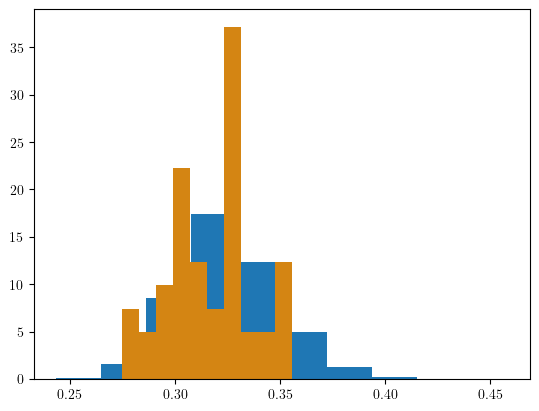

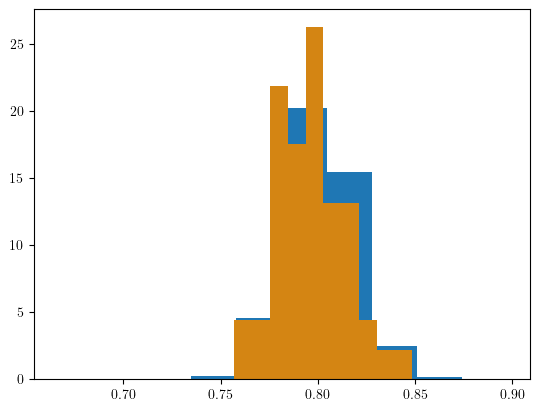

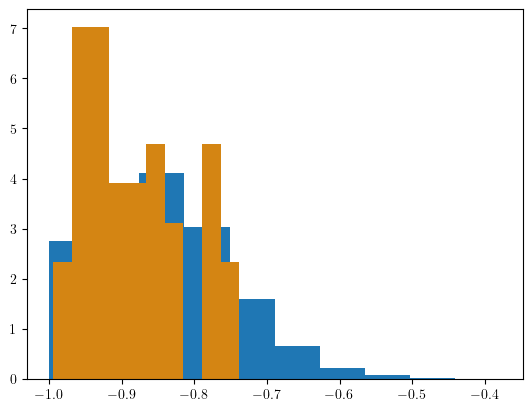

In [567]:
plt.hist(Y_targ[:, 0], density=True)
plt.hist(samples[:, 0], density=True)
plt.hist(X_prop[sel_idxs][:, 0], density=True, alpha=0.2)
plt.show()

plt.hist(Y_targ[:, 1], density=True)
plt.hist(samples[:, 1], density=True)
plt.hist(X_prop[sel_idxs][:, 1], density=True, alpha=0.2)
plt.show()
plt.hist(Y_targ[:, 2], density=True)
plt.hist(samples[:, 2], density=True)
plt.hist(X_prop[sel_idxs][:, 2], density=True, alpha=0.2)
plt.show()


In [537]:
rad, dsts

(array([0.0356627 , 0.02526125, 0.13959578], dtype=float32),
 array([0.4185916 , 0.4185916 , 0.4185916 , ..., 0.51738155, 0.51738155,
        0.51738155], dtype=float32))

In [538]:
centre, X_prop.shape

(array([ 0.32565647,  0.8017902 , -0.8444843 ], dtype=float32), (2828, 3))

(array([4., 0., 0., 8., 0., 0., 8., 4., 0., 8.]),
 array([-0.86607093, -0.86046553, -0.85486013, -0.84925473, -0.84364933,
        -0.83804393, -0.83243859, -0.82683319, -0.82122779, -0.81562239,
        -0.81001699]),
 <BarContainer object of 10 artists>)

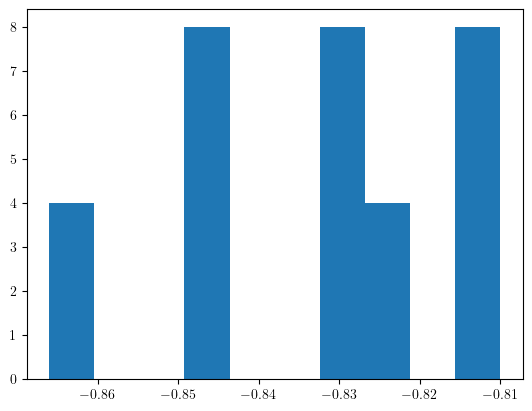

In [532]:
# find samples within epsilon ball of posterior
centre = hybrid.reshape(-1, 3).mean(0)
rad = hybrid.reshape(-1,3).std(0) * 1.5

mtrc = lambda d: np.sqrt(np.linalg.norm(d - centre))
dsts = np.array([mtrc(x) for x in X_prop])

msk = dsts < 0.2
plt.hist(X_prop[msk][:, 2])

In [533]:
all_cls_test.shape, msk.shape, cls_target.shape, ellvals.shape

((2828, 10, 28), (2828,), (10, 28), (28,))

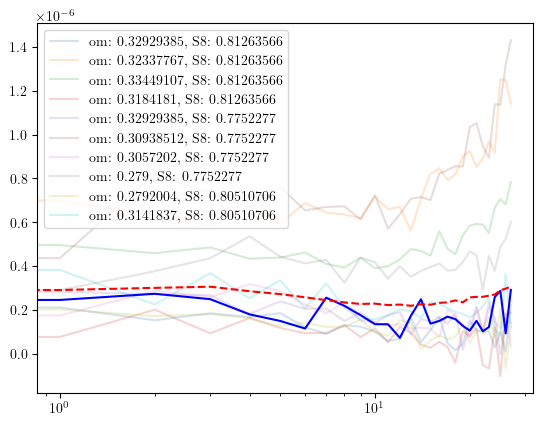

In [539]:
bin = cl_index["2_3"]

for i in range(10):
    plt.plot(all_cls_test[sel_idxs][i, bin, :], alpha=0.2, label="om: " + str(X_prop[sel_idxs][i, 0]) + "," + "  S8: " + str(X_prop[msk][i, 1]))

plt.plot(cls_target[bin, :], c='b')

plt.plot(np.mean(all_cls_test[sel_idxs], 0)[bin, :], ls='--', c='r')
plt.xscale('log')
# plt.yscale('log')
plt.legend()

In [144]:
cls_target.shape

(10, 28)

In [145]:
all_cls_test.shape

(1828, 10, 28)

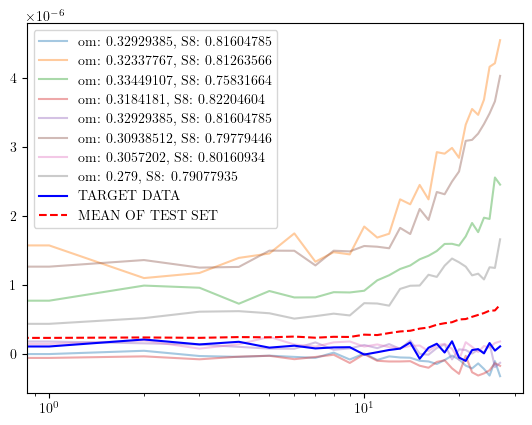

In [540]:
bin = 3

for i in range(8):
    plt.plot(all_cls_test[sel_idxs][i, bin, :], alpha=0.4, label="om: " + str(X_prop[sel_idxs][i, 0]) + "," + "  S8: " + str(X_prop[sel_idxs][i, 1]))

plt.plot(cls_target[bin, :], c='b', label="TARGET DATA")

plt.plot(np.mean(all_cls_test[sel_idxs], 0)[bin, :], ls='--', c='r', label='MEAN OF TEST SET')
plt.xscale('log')
# plt.yscale('log')
plt.legend()
# plt.yscale('log')
# plt.ylim(0, 2e-6)
# plt.yscale('log')

In [461]:

nmt_ell = np.array([12.5, 23.5, 37.5, 55.0, 75.5, 99.5, 127.5, 158.5, 192.5, 230.5, 271.5, 316.0, 
       364.0, 415.0, 469.5, 527.5, 589.0, 653.5, 721.5, 793.0, 868.0, 946.0, 
       1027.5, 1112.5, 1200.5, 1292.5, 1387.5, 1485.5])
nmt_ell.shape, ellvals.shape

((28,), (28,))

In [383]:
ress_err_p, ress_err_m

(array([36.68068043, 11.50528523, 11.78126367, 12.75340279, 10.58626913,
         8.67838411,  8.58578494,  6.87353038,  7.08979058,  7.10204678,
         6.58124484,  6.51174223,  6.19929669,  5.92973614,  6.0237887 ,
         5.64541709,  5.2678371 ,  5.41000462,  4.98953661,  4.73758079,
         4.36087899,  4.08228105,  3.83402098,  3.50884976,  3.17214103,
         2.74834483,  2.56978132,  2.33016631]),
 array([-12.04160951,  -4.6092882 ,  -5.05859908,  -4.90090166,
         -4.22624418,  -3.66521409,  -3.47722195,  -2.92677314,
         -3.09940033,  -3.16625105,  -3.04395915,  -2.98443289,
         -2.84347929,  -2.74090934,  -2.74740078,  -2.6123741 ,
         -2.4496806 ,  -2.43457357,  -2.23844826,  -2.16573133,
         -2.01522634,  -1.86755137,  -1.74923208,  -1.60761452,
         -1.44828559,  -1.28041579,  -1.19066141,  -1.07993343]))

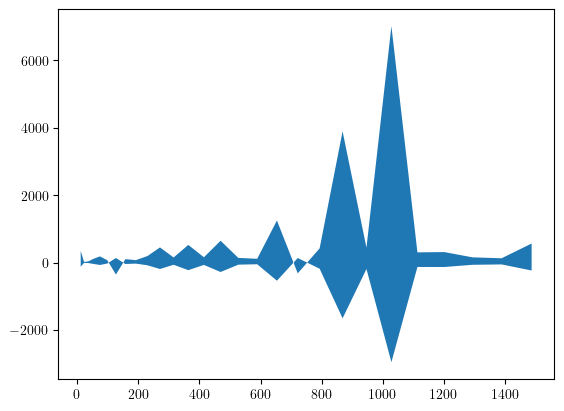

In [541]:
mu = (all_cls_test[sel_idxs][:, 0, :].mean(0))
std = (all_cls_test[sel_idxs][:, 0, :].std(0))

ress = (mu / (cls_target)[0, :]) - 1
ress_err_p = ((mu + std) / (cls_target)[0, :]) - 1
ress_err_m = ((mu - std) / (cls_target)[0, :]) - 1

plt.fill_between(x = ellvals,
                 y1 = ress_err_m,
                 y2 = ress_err_p
                )

In [573]:
ellvals[22]

1027.5

cut
cut
cut
cut
cut
cut
cut
cut
cut
cut
loop


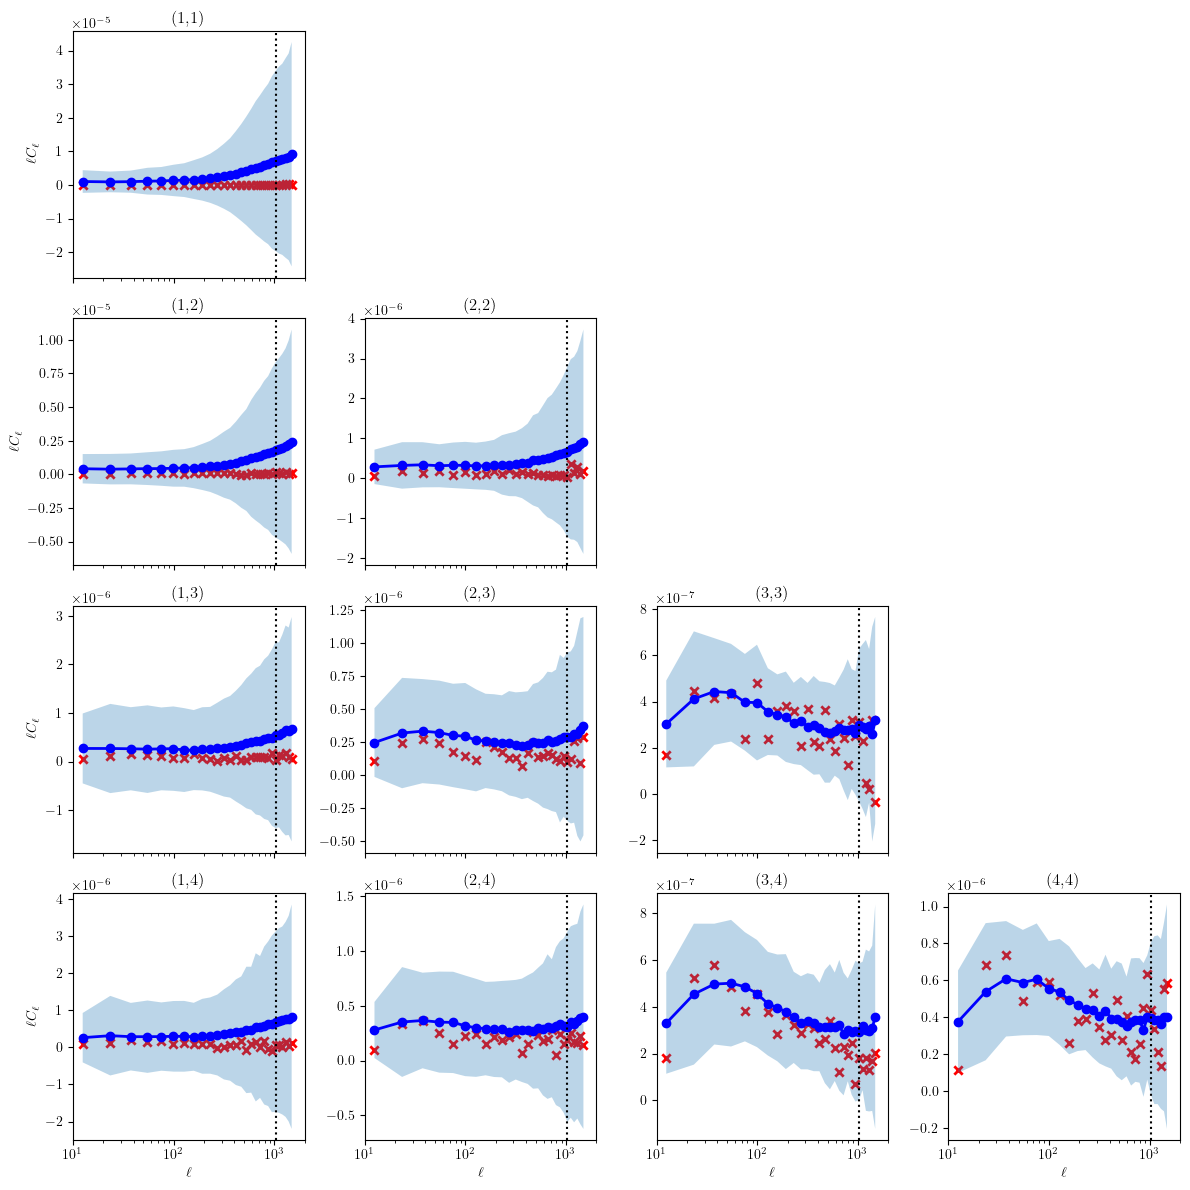

In [581]:
# x = nmt_ell
# y = mock_cls          # shape (4, npts)
# y_ref = theory_cls    # same shape
# yerr = cov_sigma      # (4, npts)

fig, axes = triangle_plot(
    ellvals,
    ellvals * cls_target,
    # cls_weighted_mean,
    y_ref=ellvals * np.average(all_cls_test[sel_idxs], 0),
    yerr=ellvals * 2 *all_cls_test[sel_idxs].std(0),
    
    xscale="log",
    yscale="linear",
    xlabel=r"$\ell$",
    ylabel=r"$\ell C_\ell$",
    res_ylabel=r"$C_\ell^\mathrm{post}/C_\ell^\mathrm{data}-1$",
    plot_kwargs=dict(lw=2),
    res_kwargs=dict(marker=None, linestyle="--"),
    show_residuals=False,
    cut_idx=22
)
plt.tight_layout()
plt.show()

loop


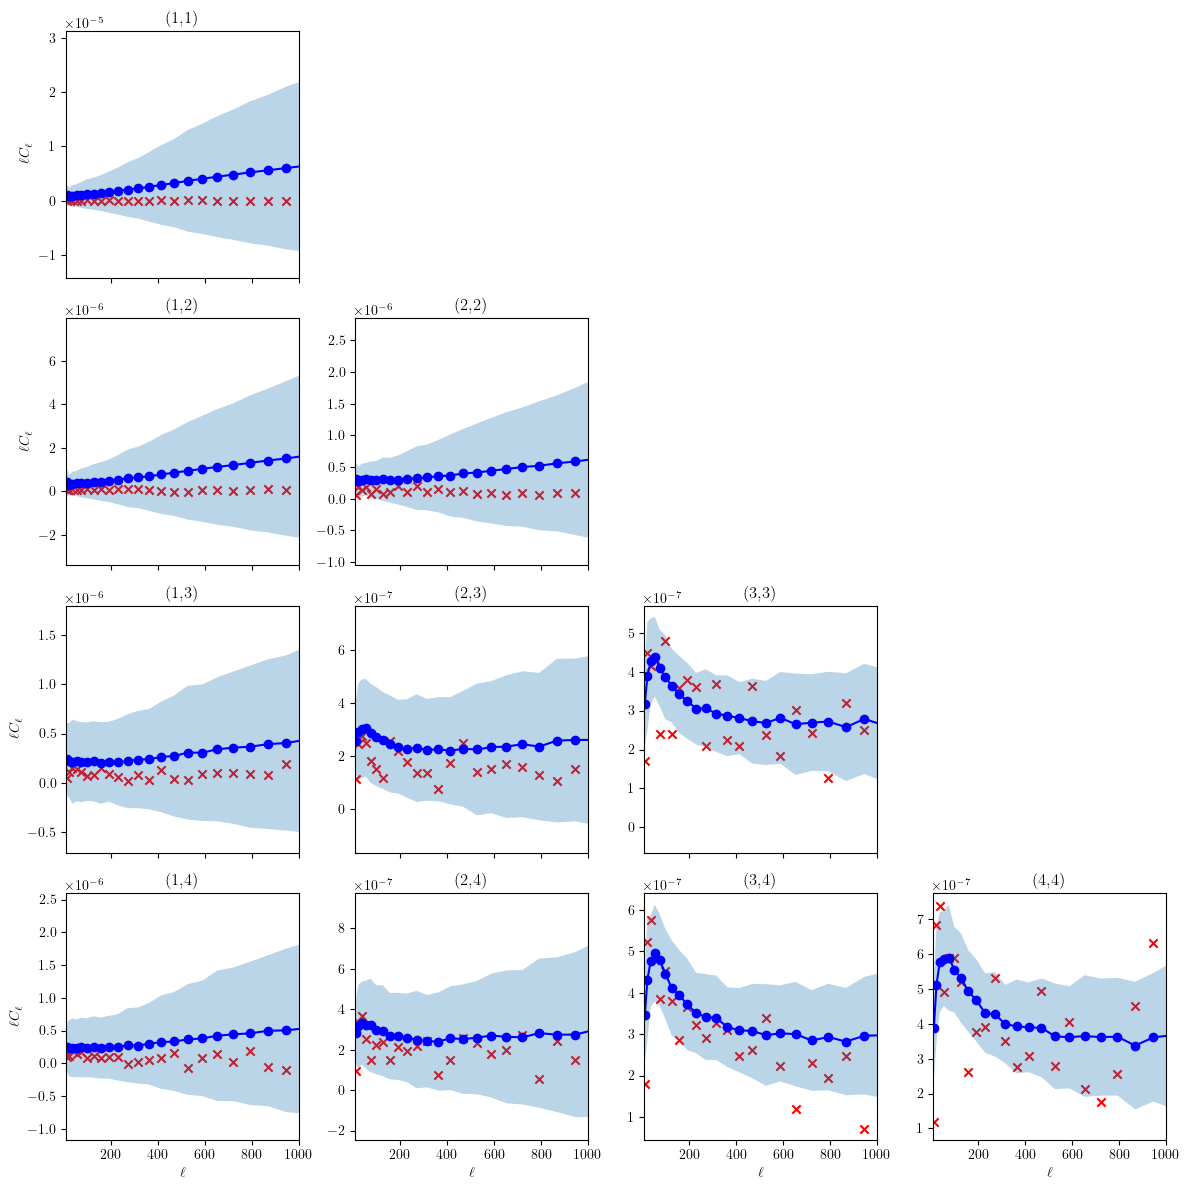

In [558]:
# x = nmt_ell
# y = mock_cls          # shape (4, npts)
# y_ref = theory_cls    # same shape
# yerr = cov_sigma      # (4, npts)

fig, axes = triangle_plot(
    ellvals,
    cls_target,
    # cls_weighted_mean,
    y_ref=np.average( all_cls_test[sel_idxs], 0),
    yerr=(all_cls_test[sel_idxs]).std(0),
    
    xscale="linear",
    yscale="linear",
    xlabel=r"$\ell$",
    ylabel=r"$\ell C_\ell$",
    res_ylabel=r"$C_\ell^\mathrm{post}/C_\ell^\mathrm{data}-1$",
    #plot_kwargs=dict(color="k", lw=2),
    res_kwargs=dict(marker=None, linestyle="--"),
    show_residuals=False,
    cut_idx=22
)
plt.tight_layout()
plt.show()


In [29]:
params_test[0], other_params_test[0]

(array([0.33161303, 0.48893237, 0.5124558 ], dtype=float32),
 array([0.45952517, 0.50293326, 0.522881  ], dtype=float32))

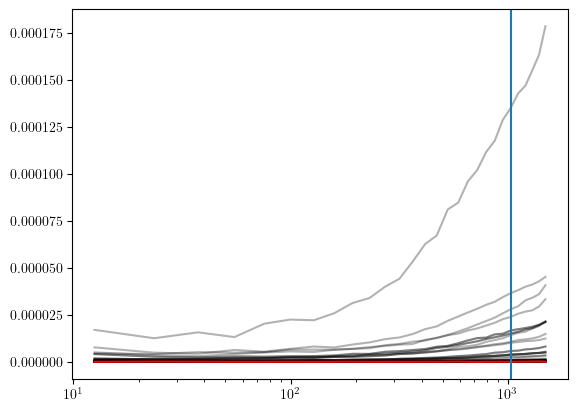

In [525]:
b = 0 # 4, 7, 9
for i in range(50):
    plt.plot(ellvals, all_cls_test[sel_idxs][i, b, :][::], alpha=0.3, c='k')

plt.plot(ellvals, cls_target[b,  :][::], c='r')
plt.axvline(ellvals[22])

plt.xscale('log')
# plt.yscale('log')

plt.show()

In [498]:
ellvals

array([  12.5,   23.5,   37.5,   55. ,   75.5,   99.5,  127.5,  158.5,
        192.5,  230.5,  271.5,  316. ,  364. ,  415. ,  469.5,  527.5,
        589. ,  653.5,  721.5,  793. ,  868. ,  946. , 1027.5, 1112.5,
       1200.5, 1292.5, 1387.5, 1485.5])

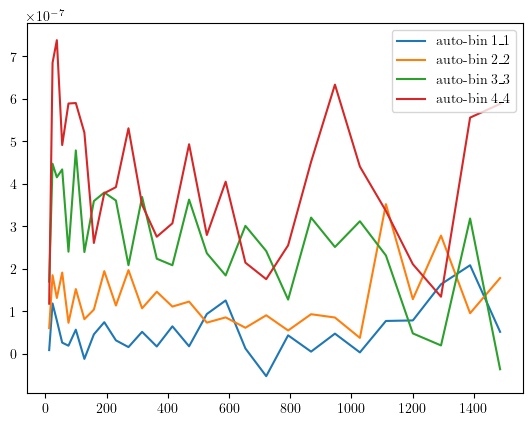

In [527]:
labs = ["1_1", "2_2", "3_3", "4_4"]
for i,b in enumerate([0, 4, 7, 9]):
    plt.plot(ellvals, cls_target[b,  :][::], label='auto-bin %s'%(labs[i]))

plt.legend()
# plt.xscale('log')


In [304]:
all_cls_test.shape

(2828, 10, 28)

## plot the NDE and baryon test results

In [17]:
target_blind_singles = np.load("/Users/lucas/repositories/des-hybrid/results/blind_single_nde_mcmc_samples.npy")
target_blind_singles.shape

(4, 160000, 3)

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


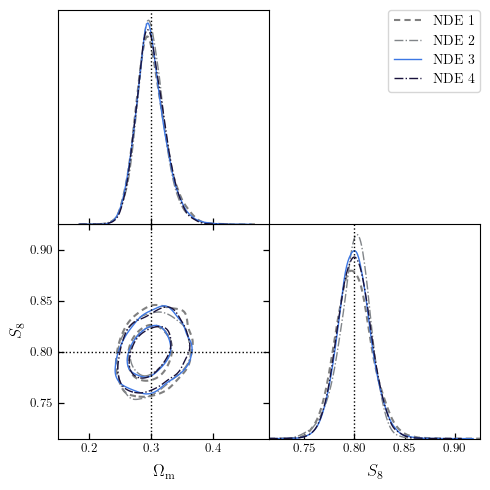

In [76]:
#colors = ['#003F5C', '#BC5090', '#FF6361', '#FFA600']
# colors = [ '#3c77e4', '#9D3B6C','#FFA600' , '#19123C', '#3c77e4']

colors = [ 'gray', 
          # '#36454F' , 
          "#818589",
          # '#183e41',
           '#377863',
          # 'k' , 
          # '#3c77e4',
          '#19123C', '#3c77e4']


colors = [ 'gray', 
          "#818589",
           "#3c77e4",
          # '#183e41',
          # '#377863',
          # 'k' , 
          # '#3c77e4',
          '#19123C', '#3c77e4']


prior_om = [0.15, 0.49]
prior_s8 = [0.5, 1.]
prior_w = [-1, -0.33]
prior_IA = [-3, 3.]

n_burn2d = 0

chain_cosmic_shear = './results/desy3_shear_wcdmnu_hyperrank_noSR_2.txt'
uu = np.genfromtxt(chain_cosmic_shear, names=True)
mask = uu['cosmological_parametersomega_m'] > 0.1

label_marco = '2nd+3rd mom.+ST+WPH'
label_betti = r'2nd mom.+Betti'
label_cs = r'Cosmic Shear $\xi_{\pm}$'

# Plot settings
param_limits_plot = {
        'Om': (0.15, 0.49),
        's8': (0.715, 0.925),
        #'s8': (0.5, 1.2),
        'w': (-1, -0.33),
        'IA': (-2, 2)
    }



def reweight(p, mu, sigma):
    likelihood_gaussian = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((p - mu) / sigma)**2)
    likelihood_flat = 1.0  # Flat prior
    weight = likelihood_gaussian / likelihood_flat
    return weight

w1 = reweight(uu['cosmological_parametersh0'], 0.7022, 0.0245)
#w2 = reweight(uu['cosmological_parametersomega_b'], 0.9649, 0.0063)  
w2 = reweight(uu['cosmological_parametersn_s'], 0.9649, 0.0063)  
w3 = reweight((uu['cosmological_parametersomega_b'])*uu['cosmological_parametersh0']**2, 0.02237, 0.00015)  
#w3 = reweight(uu['cosmological_parametersomega_b'], 0.04553, 0.00320)  

names = ['Om', 's8', 'w']
labels = [r'\Omega_{\rm m}', 'S_8', 'w']
ranges = {'Om': prior_om, 's8': prior_s8, 'w': prior_w}

blob_labels = ["NDE %d"%(i+1) for i in range(4)]

samples_nde = []

for i in range(4):

    samples_nde.append(MCSamples(samples=[target_blind_singles[i][burnin_niall:,0].flatten(),
                                    target_blind_singles[i][burnin_niall:,1].flatten(), ],
                                                     names=['Om', 's8'],
                     labels=labels,
                    label=blob_labels[i],
                    settings={'mult_bias_correction_order': 1,
                              'smooth_scale_2D': 0.4,
                              'smooth_scale_1D': 0.2},
                    ranges=ranges
                                )
                      )
        


# Configure plot aesthetics
g = plots.get_subplot_plotter(width_inch=5)


g.settings.alpha_filled_add = 0.9
g.settings.alpha_factor_contour_lines = 0.4



# Plot the triangle plot with customized settings
g.triangle_plot(samples_nde, ['Om', 's8'], 
                legend_loc='upper right',legend_title='DES Y3', 
                filled=[False, False, False, False, False],
                contour_ls = ['--','dashdot', '-', 'dashdot','-'],  
                contour_lws=[1.5,1,1,1],
                contour_colors= colors, param_limits=param_limits_plot,
                title_limit=None, diag1d_kwargs=dict(normalized=True))


for ax in g.subplots[:, 0]:
    ax.axvline(0.3, color="k", ls=":", lw=1)

# for ax in g.subplots[0, :]:
g.subplots[1,0].axhline(0.8, color="k", ls=":", lw=1)
g.subplots[1,1].axvline(0.8, color="k", ls=":", lw=1)

        
# Save the figure
plt.savefig('./paper/plots/' + 'DESY3_blind_nde.png', dpi=500)
plt.savefig('./paper/plots/' + 'DESY3_blind_nde.pdf', dpi=500)


In [78]:
chains_baryons = np.load("/Users/lucas/repositories/des-hybrid/results/final_baryon_test.npz")["chains_baryons"][::5]
chains_no_baryons = np.load("/Users/lucas/repositories/des-hybrid/results/final_baryon_test.npz")["chains_no_baryons"][::5]

Removed no burn in
Removed no burn in


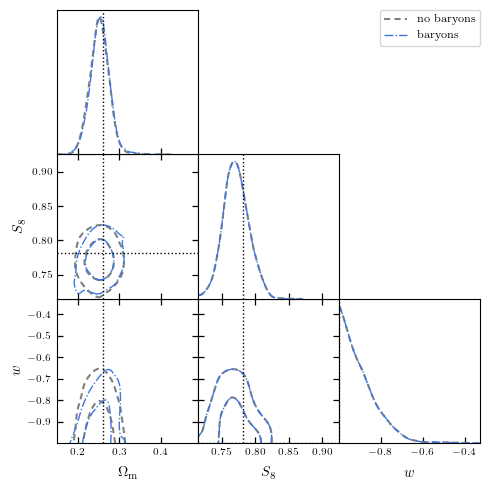

In [94]:
#colors = ['#003F5C', '#BC5090', '#FF6361', '#FFA600']
# colors = [ '#3c77e4', '#9D3B6C','#FFA600' , '#19123C', '#3c77e4']

colors = [ 'gray', 
          # '#36454F' , 
          "#818589",
          # '#183e41',
           '#377863',
          # 'k' , 
          # '#3c77e4',
          '#19123C', '#3c77e4']


colors = [ 'gray', 
          #"#818589",
           "#3c77e4",
          # '#183e41',
          # '#377863',
          # 'k' , 
          # '#3c77e4',
          '#19123C', '#3c77e4']


prior_om = [0.15, 0.49]
prior_s8 = [0.5, 1.]
prior_w = [-1, -0.33]
prior_IA = [-3, 3.]

n_burn2d = 0

chain_cosmic_shear = './results/desy3_shear_wcdmnu_hyperrank_noSR_2.txt'
uu = np.genfromtxt(chain_cosmic_shear, names=True)
mask = uu['cosmological_parametersomega_m'] > 0.1

label_marco = '2nd+3rd mom.+ST+WPH'
label_betti = r'2nd mom.+Betti'
label_cs = r'Cosmic Shear $\xi_{\pm}$'

# Plot settings
param_limits_plot = {
        'Om': (0.15, 0.49),
        's8': (0.715, 0.925),
        #'s8': (0.5, 1.2),
        'w': (-1, -0.33),
        'IA': (-2, 2)
    }



def reweight(p, mu, sigma):
    likelihood_gaussian = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((p - mu) / sigma)**2)
    likelihood_flat = 1.0  # Flat prior
    weight = likelihood_gaussian / likelihood_flat
    return weight

w1 = reweight(uu['cosmological_parametersh0'], 0.7022, 0.0245)
#w2 = reweight(uu['cosmological_parametersomega_b'], 0.9649, 0.0063)  
w2 = reweight(uu['cosmological_parametersn_s'], 0.9649, 0.0063)  
w3 = reweight((uu['cosmological_parametersomega_b'])*uu['cosmological_parametersh0']**2, 0.02237, 0.00015)  
#w3 = reweight(uu['cosmological_parametersomega_b'], 0.04553, 0.00320)  

names = ['Om', 's8', 'w']
labels = [r'\Omega_{\rm m}', 'S_8', 'w']
ranges = {'Om': prior_om, 's8': prior_s8, 'w': prior_w}


samples_bary = (MCSamples(samples=[chains_baryons[burnin_niall:,0].flatten(),
                                    chains_baryons[burnin_niall:,1].flatten(), 
                                    chains_baryons[burnin_niall:,2].flatten(), ],
                                                 names=['Om', 's8', 'w'],
                 labels=labels,
                label="baryons",
                settings={'mult_bias_correction_order': 1,
                          'smooth_scale_2D': 0.4,
                          'smooth_scale_1D': 0.2},
                ranges=ranges
                            )
                  )


samples_no_bary = (MCSamples(samples=[chains_no_baryons[burnin_niall:,0].flatten(),
                                    chains_baryons[burnin_niall:,1].flatten(), 
                                    chains_baryons[burnin_niall:,2].flatten(), ],
                                                 names=['Om', 's8', 'w'],
                 labels=labels,
                label="no baryons",
                settings={'mult_bias_correction_order': 1,
                          'smooth_scale_2D': 0.4,
                          'smooth_scale_1D': 0.2},
                ranges=ranges
                            )
                  )
        


# Configure plot aesthetics
g = plots.get_subplot_plotter(width_inch=5)


g.settings.alpha_filled_add = 0.9
g.settings.alpha_factor_contour_lines = 0.4



# Plot the triangle plot with customized settings
g.triangle_plot([samples_no_bary, samples_bary], ['Om', 's8', 'w'], 
                legend_loc='upper right',legend_title='DES Y3', 
                filled=[False, False, False, False, False],
                contour_ls = ['--','dashdot', '-', 'dashdot','-'],  
                contour_lws=[1.5,1,1,1],
                contour_colors= colors, param_limits=param_limits_plot,
                title_limit=None, diag1d_kwargs=dict(normalized=True))


theta_true_baryons = np.array([0.26      ,  0.78199744, -1.0])

for ax in g.subplots[:, 0]:
    ax.axvline(theta_true_baryons[0], color="k", ls=":", lw=1)

g.subplots[1,0].axhline(theta_true_baryons[1], color="k", ls=":", lw=1)
g.subplots[1,1].axvline(theta_true_baryons[1], color="k", ls=":", lw=1)
g.subplots[2,1].axvline(theta_true_baryons[1], color="k", ls=":", lw=1)


g.subplots[2,1].axhline(theta_true_baryons[2], color="k", ls=":", lw=1)
g.subplots[2,2].axvline(theta_true_baryons[2], color="k", ls=":", lw=1)
# Save the figure
plt.savefig('./paper/plots/' + 'DESY3_baryontest.png', dpi=500)
plt.savefig('./paper/plots/' + 'DESY3_baryontest.pdf', dpi=500)


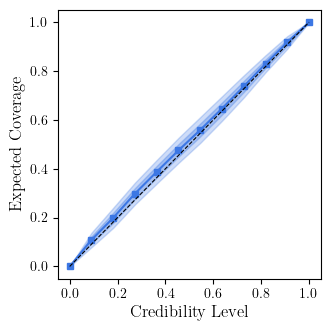

In [23]:
# coverage_file = np.load('./results/coverage_results_12_11.npz')
# coverage_file = np.load('./results/coverage_final_19_12_longer_run.npz')

# coverage_file = np.load('./results/coverage_final_05_01_manhattan2.npz')
# coverage_file = np.load('./results/coverage_leaveoneout_13_01.npz')
# coverage_file = np.load('./results/coverage_leaveoneout_reweighted_prior_14_01.npz')
coverage_file = np.load('./results/coverage_leaveoneout_gauss_26_01_run2.npz')
coverage_file = np.load('./results/coverage_leaveoneout_gauss_13_04_7summs_vic_gelu_nolayernorm2.npz')

# coverage_file = np.load('./results/coverage_leaveoneout_gauss_23_02_run2.npz')

# coverage_file = np.load('./results/coverage_leaveoneout_gauss_02_03_run4_n200.npz')


alpha = coverage_file['alpha']
ecp = coverage_file['ecp']


fig = plt.figure(figsize=(3.41 , 3.41))
ecp_mean = np.mean(ecp, axis=0)
ecp_std = np.std(ecp, axis=0)
plt.plot(alpha, ecp_mean, label='TARP', color='#3c77e4',  marker='s', markersize=5)
plt.fill_between(alpha, ecp_mean - ecp_std, ecp_mean + ecp_std,
                alpha=0.3, color="#3c77e4")
plt.fill_between(alpha, ecp_mean - 2 * ecp_std, ecp_mean + 2 * ecp_std,
                alpha=0.25, color="#3c77e4")

# plt.fill_between(alpha, ecp_mean - 3 * ecp_std, ecp_mean + 3 * ecp_std,
#                 alpha=0.2, color="#3c77e4")

plt.plot([0, 1], [0, 1], ls='--', color='k', lw=0.8)


plt.xlabel('Credibility Level', fontsize=12)
plt.ylabel('Expected Coverage', fontsize=12)
plt.tight_layout()
plt.savefig("./paper/plots/final_coverage_13_04.pdf", dpi=400)
# plt.savefig("./paper/plots/pngs/example_coverage.png", dpi=400)

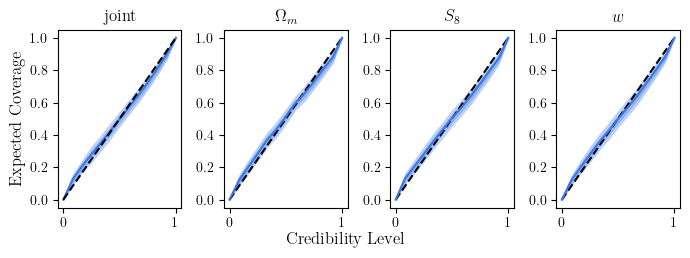

In [52]:






labels = [r"$\Omega_m$", r"$S_8$", r"$w$"]
coverage_marginals = np.load('./results/marginal_coverage_05_01.npz')

ecp_marginals = coverage_marginals["ecp"]
_alpha = coverage_marginals["alpha"]

fig, axs = plt.subplots(1, 4, figsize=(7,2.5), sharex=True)



for i in range(3):
    ax = axs[i + 1]
    ecp_mean_i = np.mean(ecp_marginals[i], axis=0)
    ecp_std_i = np.std(ecp_marginals[i], axis=0)
    ax.plot([0, 1], [0, 1], ls='--', color='k')
    ax.plot(_alpha, ecp_mean_i, label='TARP', color='#3c77e4')
    ax.fill_between(_alpha, ecp_mean_i - ecp_std_i, ecp_mean_i + ecp_std_i,
                    alpha=0.3, color='#3c77e4')
    ax.fill_between(_alpha, ecp_mean_i - 2 * ecp_std_i, ecp_mean_i + 2 * ecp_std_i,
                    alpha=0.25, color='#3c77e4')

    ax.set_title(labels[i])




coverage_file = np.load('./results/coverage_final_05_01_manhattan2.npz')


alpha = coverage_file['alpha']
ecp = coverage_file['ecp']

ecp_mean = np.mean(ecp, axis=0)
ecp_std = np.std(ecp, axis=0)

ax = axs[0]


ax.plot(alpha, ecp_mean, label='TARP', color='#3c77e4')
ax.fill_between(alpha, ecp_mean - ecp_std, ecp_mean + ecp_std,
                alpha=0.3, color="#3c77e4")
ax.fill_between(alpha, ecp_mean - 2 * ecp_std, ecp_mean + 2 * ecp_std,
                alpha=0.25, color="#3c77e4")

# plt.fill_between(alpha, ecp_mean - 3 * ecp_std, ecp_mean + 3 * ecp_std,
#                 alpha=0.2, color="#3c77e4")

ax.plot([0, 1], [0, 1], ls='--', color='k')#, lw=0.8)

ax.set_title('joint')
# ax.set_xlabel('Credibility Level', fontsize=12)
ax.set_ylabel('Expected Coverage', fontsize=12)
fig.text(0.5, 0.0, 'Credibility Level', ha='center', fontsize=12)
plt.tight_layout()
# plt.savefig("./paper/plots/example_coverage_05_01.pdf", dpi=400)
# plt.savefig("./paper/plots/pngs/example_coverage.png", dpi=400)

## summary visualisation

In [24]:
summary_file = np.load("./density_estimation/local_testing/final_nde_19_11/formatted_summaries.npz")

summary_file = np.load("/Users/lucas/repositories/compress-des/ndes_7summaries_vic_gelu_nolayernorm2/formatted_summaries.npz")


summaries_to_plot = summary_file["preds_test"]
params_to_plot = summary_file["params_test"]
target_summaries = summary_file["summs_target"]

param_labels = [r'$\Omega_m$', r'$S_8$', r'$w$']


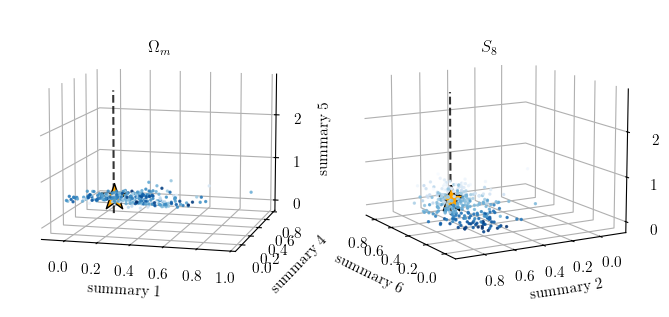

In [25]:

from mpl_toolkits.mplot3d import Axes3D  # Required for 3D plotting

# Generate some dummy data for demonstration
num_samples = 100  # Replace with your actual number of samples

# 'summary' is a (num_samples, 7) array; modify accordingly if your data differs

# 'parameters' is a (num_samples, 3) array

# Choose which dimensions to plot:
# For example:
#  - summary[:, 0] for x-axis,
#  - summary[:, 1] for y-axis,
#  - parameters[:, 0] for z-axis.

p_idx1 = 0
# p_idx2 = 1
s_idx1 = 0
s_idx2 = 3
s_idx3 = 4


cmap_ = "Blues_r"
alpha_ = 0.8
scattersize = 2.0

skip = 10

x = summaries_to_plot[::skip, s_idx1]
y = summaries_to_plot[::skip, s_idx2]
z = summaries_to_plot[::skip, s_idx3]
c = params_to_plot[::skip, p_idx1]

# Create a figure and a 3D subplot
fig = plt.figure(figsize=(3.41 * 2, 3.41))




ax = fig.add_subplot(121, projection='3d')

# Create a scatter plot with a colormap based on z values
scatter = ax.scatter(x, y, z, c=c, cmap=cmap_, s=scattersize, alpha=alpha_)


# plot target as well.
_ =  ax.scatter(target_summaries[:, s_idx1], target_summaries[:, s_idx2], \
                target_summaries[:, s_idx3], facecolor='orange', \
                edgecolor='k',
                marker='*', s=400, zorder=1000000)

# plot vertical line at target
ax.plot(target_summaries[:, s_idx1] * np.ones(30), target_summaries[:, s_idx2] * np.ones(30), \
        np.linspace(z.min(), (z.max() + 2), 30), 
        'k--',alpha=0.8, linewidth=1.5)


# Set labels for clarity
ax.set_xlabel('summary %d'%(s_idx1+1), fontsize=11)
ax.set_ylabel('summary %d'%(s_idx2+1), fontsize=11)
ax.set_zlabel('summary %d'%(s_idx3+1), fontsize=11)

# Adjust the viewing angle: elev (elevation) and azim (azimuth)
ax.view_init(elev=10, azim=285, roll=0)  # 

# Change fontsize for tick labels on all axes
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=11)
ax.tick_params(axis='z', labelsize=11)

ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))

# Optionally add a colorbar to link the color scale with the z values
#fig.colorbar(scatter, ax=ax, label='Parameter Dimension %d'%(p_idx2))

# ax.set_xticks([])
# ax.set_yticks([])

if hasattr(ax, 'xaxis'):
    ax.xaxis._axinfo["grid"]['visible'] = False
    ax.yaxis._axinfo["grid"]['visible'] = False
    ax.zaxis._axinfo["grid"]['visible'] = False

ax.set_title(param_labels[p_idx1], fontsize=12, y=0.9)

# ___________________________________________________________________________

p_idx1 = 1
# p_idx2 = 1
s_idx1 = 5
s_idx2 = 1
s_idx3 = 4


x = summaries_to_plot[::skip, s_idx1]
y = summaries_to_plot[::skip, s_idx2]
z = summaries_to_plot[::skip, s_idx3]
c = params_to_plot[::skip, p_idx1]

ax = fig.add_subplot(122, projection='3d')

# Create a scatter plot with a colormap based on z values
scatter = ax.scatter(x, y, z, c=c, cmap=cmap_, s=scattersize, alpha=alpha_)


# plot target as well.
_ =  ax.scatter(target_summaries[:, s_idx1], target_summaries[:, s_idx2], \
                target_summaries[:, s_idx3], facecolor='orange', \
                edgecolor='k', alpha=1.0,
                marker='*', s=400, zorder=10, depthshade=False)


# plot vertical line at target
ax.plot(target_summaries[:, s_idx1] * np.ones(30), target_summaries[:, s_idx2] * np.ones(30), \
        np.linspace(z.min(), (z.max() + 2), 30), 
        'k--',alpha=0.8, linewidth=1.5)

# Set labels for clarity
ax.set_xlabel('summary %d'%(s_idx1+1), fontsize=11)
ax.set_ylabel('summary %d'%(s_idx2+1), fontsize=11)
ax.set_zlabel('summary %d'%(s_idx3+1), fontsize=11)

# Adjust the viewing angle: elev (elevation) and azim (azimuth)
ax.view_init(elev=12, azim=150, roll=0)  # 

# Change fontsize for tick labels on all axes
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=11)
ax.tick_params(axis='z', labelsize=11)

ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))

# Optionally add a colorbar to link the color scale with the z values
#fig.colorbar(scatter, ax=ax, label='Parameter Dimension %d'%(p_idx2))

# ax.set_xticks([])
# ax.set_yticks([])


if hasattr(ax, 'xaxis'):
    ax.xaxis._axinfo["grid"]['visible'] = False
    ax.yaxis._axinfo["grid"]['visible'] = False
    ax.zaxis._axinfo["grid"]['visible'] = False

ax.set_title(param_labels[p_idx1], fontsize=12, y=0.9)

# Display the plot
plt.tight_layout(pad=1.55)

# save
plt.savefig('./paper/plots/' + 'summary_scatter.pdf', dpi=500)
plt.savefig('./paper/plots/' + 'summary_scatter.png', dpi=500)

plt.show()

/var/folders/pg/xm7nmkzn0tq26tlbl6skh5080000gp/T/ipykernel_60083/3602145569.py:235: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  plt.tight_layout(pad=-1.0)


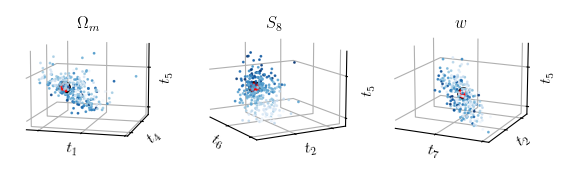

In [26]:

from mpl_toolkits.mplot3d import Axes3D  # Required for 3D plotting

# Generate some dummy data for demonstration
num_samples = 100  # Replace with your actual number of samples

# 'summary' is a (num_samples, 7) array; modify accordingly if your data differs

# 'parameters' is a (num_samples, 3) array

# Choose which dimensions to plot:
# For example:
#  - summary[:, 0] for x-axis,
#  - summary[:, 1] for y-axis,
#  - parameters[:, 0] for z-axis.

# ___________________________________________________________________________
# FOR Om
# ___________________________________________________________________________


p_idx1 = 0
# p_idx2 = 1
s_idx1 = 0
s_idx2 = 3
s_idx3 = 4


cmap_ = "Blues"
alpha_ = 0.8
scattersize = 1.0

labelpad = -12

skip = 10

x = summaries_to_plot[::skip, s_idx1]
y = summaries_to_plot[::skip, s_idx2]
z = summaries_to_plot[::skip, s_idx3]
c = params_to_plot[::skip, p_idx1]

# Create a figure and a 3D subplot
fig = plt.figure(figsize=(3.41 * 2, 3.41 * 1))




ax = fig.add_subplot(131, projection='3d')

# Create a scatter plot with a colormap based on z values
scatter = ax.scatter(x, y, z, c=c, cmap=cmap_, s=scattersize, alpha=alpha_)


# plot target as well.
_ =  ax.scatter(target_summaries[:, s_idx1], target_summaries[:, s_idx2], \
                target_summaries[:, s_idx3], facecolor='r', \
                edgecolor='k',
                marker='o', s=67, zorder=1000000)

# plot vertical line at target
# ax.plot(target_summaries[:, s_idx1] * np.ones(30), target_summaries[:, s_idx2] * np.ones(30), \
#         np.linspace(z.min(), (z.max() + 2), 30), 
#         'k--',alpha=0.8, linewidth=1.5)


# Set labels for clarity
ax.set_xlabel(r'$t_%d$'%(s_idx1+1), fontsize=11, labelpad=labelpad)
ax.set_ylabel(r'$t_%d$'%(s_idx2+1), fontsize=11, labelpad=labelpad)
ax.set_zlabel(r'$t_%d$'%(s_idx3+1), fontsize=11, labelpad=labelpad)

# Adjust the viewing angle: elev (elevation) and azim (azimuth)
ax.view_init(elev=10, azim=285, roll=0)  # 

# Change fontsize for tick labels on all axes
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=11)
ax.tick_params(axis='z', labelsize=11)

ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))

# Optionally add a colorbar to link the color scale with the z values
#fig.colorbar(scatter, ax=ax, label='Parameter Dimension %d'%(p_idx2))

# ax.set_xticks([])
# ax.set_yticks([])
ax.set_zticklabels([])
ax.set_yticklabels([])
ax.set_xticklabels([])

if hasattr(ax, 'xaxis'):
    ax.xaxis._axinfo["grid"]['visible'] = False
    ax.yaxis._axinfo["grid"]['visible'] = False
    ax.zaxis._axinfo["grid"]['visible'] = False
    

ax.set_title(param_labels[p_idx1], fontsize=12, y=0.9)

# ___________________________________________________________________________
# FOR S8
# ___________________________________________________________________________

p_idx1 = 1
# p_idx2 = 1
s_idx1 = 5
s_idx2 = 1
s_idx3 = 4


x = summaries_to_plot[::skip, s_idx1]
y = summaries_to_plot[::skip, s_idx2]
z = summaries_to_plot[::skip, s_idx3]
c = params_to_plot[::skip, p_idx1]

ax = fig.add_subplot(132, projection='3d')

# Create a scatter plot with a colormap based on z values
scatter = ax.scatter(x, y, z, c=c, cmap=cmap_, s=scattersize, alpha=alpha_)


# plot target as well.
_ =  ax.scatter(target_summaries[:, s_idx1], target_summaries[:, s_idx2], \
                target_summaries[:, s_idx3], facecolor='r', \
                edgecolor='k', alpha=1.0,
                marker='o', s=67, zorder=10, depthshade=False)


# plot vertical line at target
# ax.plot(target_summaries[:, s_idx1] * np.ones(30), target_summaries[:, s_idx2] * np.ones(30), \
#         np.linspace(z.min(), (z.max() + 2), 30), 
#         'k--',alpha=0.8, linewidth=1.5)

# Set labels for clarity
ax.set_xlabel(r'$t_%d$'%(s_idx1+1), fontsize=11, labelpad=labelpad)
ax.set_ylabel(r'$t_%d$'%(s_idx2+1), fontsize=11, labelpad=labelpad)
ax.set_zlabel(r'$t_%d$'%(s_idx3+1), fontsize=11, labelpad=labelpad)

# Adjust the viewing angle: elev (elevation) and azim (azimuth)
ax.view_init(elev=12, azim=150, roll=0)  # 

# Change fontsize for tick labels on all axes
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=11)
ax.tick_params(axis='z', labelsize=11)

ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))

# Optionally add a colorbar to link the color scale with the z values
#fig.colorbar(scatter, ax=ax, label='Parameter Dimension %d'%(p_idx2))

# ax.set_xticks([])
# ax.set_yticks([])
ax.set_zticklabels([])
ax.set_yticklabels([])
ax.set_xticklabels([])

if hasattr(ax, 'xaxis'):
    ax.xaxis._axinfo["grid"]['visible'] = False
    ax.yaxis._axinfo["grid"]['visible'] = False
    ax.zaxis._axinfo["grid"]['visible'] = False

ax.set_title(param_labels[p_idx1], fontsize=12, y=0.9)

# ___________________________________________________________________________
# FOR w
# ___________________________________________________________________________

p_idx1 = 2
# p_idx2 = 1
s_idx1 = 6
s_idx2 = 1
s_idx3 = 4


x = summaries_to_plot[::skip, s_idx1]
y = summaries_to_plot[::skip, s_idx2]
z = summaries_to_plot[::skip, s_idx3]
c = ((params_to_plot[::skip, p_idx1]))

ax = fig.add_subplot(133, projection='3d')

# Create a scatter plot with a colormap based on z values
scatter = ax.scatter(x, y, z, c=c, cmap=cmap_, s=scattersize, alpha=alpha_)


# plot target as well.
_ =  ax.scatter(target_summaries[:, s_idx1], target_summaries[:, s_idx2], \
                target_summaries[:, s_idx3], facecolor='r', \
                edgecolor='k', alpha=1.0,
                marker='o', s=67, zorder=10, depthshade=False)


# plot vertical line at target
# ax.plot(target_summaries[:, s_idx1] * np.ones(30), target_summaries[:, s_idx2] * np.ones(30), \
#         np.linspace(z.min(), (z.max() + 2), 30), 
#         'k--',alpha=0.8, linewidth=1.5)

# Set labels for clarity
ax.set_xlabel(r'$t_%d$'%(s_idx1+1), fontsize=11, labelpad=labelpad)
ax.set_ylabel(r'$t_%d$'%(s_idx2+1), fontsize=11, labelpad=labelpad)
ax.set_zlabel(r'$t_%d$'%(s_idx3+1), fontsize=11, labelpad=labelpad)

# Adjust the viewing angle: elev (elevation) and azim (azimuth)
ax.view_init(elev=15, azim=115, roll=0)  # 

# Change fontsize for tick labels on all axes
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=11)
ax.tick_params(axis='z', labelsize=11)

ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))

# Optionally add a colorbar to link the color scale with the z values
#fig.colorbar(scatter, ax=ax, label='Parameter Dimension %d'%(p_idx2))

# ax.set_xticks([])
# ax.set_yticks([])

ax.set_zticklabels([])
ax.set_yticklabels([])
ax.set_xticklabels([])

if hasattr(ax, 'xaxis'):
    ax.xaxis._axinfo["grid"]['visible'] = False
    ax.yaxis._axinfo["grid"]['visible'] = False
    ax.zaxis._axinfo["grid"]['visible'] = False

ax.set_title(param_labels[p_idx1], fontsize=12, y=0.9)

# Display the plot
plt.tight_layout(pad=-1.0)

# save
# plt.savefig('./paper/plots/' + 'summary_scatter.pdf', dpi=500, bbox_inches='tight')
# plt.savefig('./paper/plots/' + 'summary_scatter.png', dpi=500, bbox_inches='tight')

plt.show()

/var/folders/pg/xm7nmkzn0tq26tlbl6skh5080000gp/T/ipykernel_26298/1809611018.py:190: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout(pad=0.5)


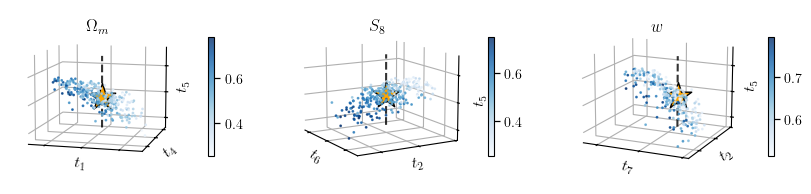

In [250]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np
# from mpl_toolkits.axes_grid1 import make_axes_locatable # Not using for simplicity


param_labels = [r'$\Omega_m$', r'$S_8$', r'$w$']
# ------------------------------------------------------


# Choose which dimensions to plot:
cmap_ = "Blues"
alpha_ = 0.8
scattersize = 1.0
labelpad = -12
skip = 10
COLORBAR_SHRINK = 0.45  # Adjust this value to visually match the Z-axis height
COLORBAR_PAD = 0.1    # Adjust this for distance from the plot

# Create a figure and a 3D subplot (1 row, 3 columns)
fig = plt.figure(figsize=(3.41 * 3, 3.41 * 1)) # Increased figure width for colorbars

# ===========================================================================
# FOR Om (Subplot 1)
# ===========================================================================

p_idx1 = 0
s_idx1 = 0
s_idx2 = 3
s_idx3 = 4

x = summaries_to_plot[::skip, s_idx1]
y = summaries_to_plot[::skip, s_idx2]
z = summaries_to_plot[::skip, s_idx3]
c = params_to_plot[::skip, p_idx1]

ax1 = fig.add_subplot(131, projection='3d')

# Create a scatter plot with a colormap based on c values
scatter1 = ax1.scatter(x, y, z, c=c, cmap=cmap_, s=scattersize, alpha=alpha_)

# Plot target and vertical line
ax1.scatter(target_summaries[:, s_idx1], target_summaries[:, s_idx2], 
            target_summaries[:, s_idx3], facecolor='orange', 
            edgecolor='k', marker='*', s=400, zorder=1000000)
ax1.plot(target_summaries[:, s_idx1] * np.ones(30), target_summaries[:, s_idx2] * np.ones(30), 
         np.linspace(z.min(), (z.max() + 2), 30), 
         'k--', alpha=0.8, linewidth=1.5)

# Set labels and view
ax1.set_xlabel(r'$t_%d$'%(s_idx1+1), fontsize=11, labelpad=labelpad)
ax1.set_ylabel(r'$t_%d$'%(s_idx2+1), fontsize=11, labelpad=labelpad)
ax1.set_zlabel(r'$t_%d$'%(s_idx3+1), fontsize=11, labelpad=labelpad) # Kept Z-label here for context

ax1.view_init(elev=10, azim=285, roll=0) 

# Styling (ticks, panes, grid)
ax1.tick_params(axis='x', labelsize=11)
ax1.tick_params(axis='y', labelsize=11)
ax1.tick_params(axis='z', labelsize=11)
ax1.set_zticklabels([]); ax1.set_yticklabels([]); ax1.set_xticklabels([])
ax1.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax1.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax1.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
if hasattr(ax1, 'xaxis'):
    ax1.xaxis._axinfo["grid"]['visible'] = False
    ax1.yaxis._axinfo["grid"]['visible'] = False
    ax1.zaxis._axinfo["grid"]['visible'] = False
ax1.set_title(param_labels[p_idx1], fontsize=12, y=0.9)

# --- ADD COLORBAR 1 ---
fig.colorbar(scatter1, ax=ax1, 
             shrink=COLORBAR_SHRINK, 
             pad=COLORBAR_PAD, 
             label=None) # Label with parameter name

# ===========================================================================
# FOR S8 (Subplot 2)
# ===========================================================================

p_idx1 = 1
s_idx1 = 5
s_idx2 = 1
s_idx3 = 4

x = summaries_to_plot[::skip, s_idx1]
y = summaries_to_plot[::skip, s_idx2]
z = summaries_to_plot[::skip, s_idx3]
c = params_to_plot[::skip, p_idx1]

ax2 = fig.add_subplot(132, projection='3d')

# Create a scatter plot with a colormap based on c values
scatter2 = ax2.scatter(x, y, z, c=c, cmap=cmap_, s=scattersize, alpha=alpha_)

# Plot target and vertical line
ax2.scatter(target_summaries[:, s_idx1], target_summaries[:, s_idx2], 
            target_summaries[:, s_idx3], facecolor='orange', 
            edgecolor='k', alpha=1.0, marker='*', s=400, zorder=10, depthshade=False)
ax2.plot(target_summaries[:, s_idx1] * np.ones(30), target_summaries[:, s_idx2] * np.ones(30), 
         np.linspace(z.min(), (z.max() + 2), 30), 
         'k--', alpha=0.8, linewidth=1.5)

# Set labels and view
ax2.set_xlabel(r'$t_%d$'%(s_idx1+1), fontsize=11, labelpad=labelpad)
ax2.set_ylabel(r'$t_%d$'%(s_idx2+1), fontsize=11, labelpad=labelpad)
ax2.set_zlabel(r'$t_%d$'%(s_idx3+1), fontsize=11, labelpad=labelpad) # Kept Z-label here for context

ax2.view_init(elev=12, azim=150, roll=0) 

# Styling (ticks, panes, grid)
ax2.tick_params(axis='x', labelsize=11)
ax2.tick_params(axis='y', labelsize=11)
ax2.tick_params(axis='z', labelsize=11)
ax2.set_zticklabels([]); ax2.set_yticklabels([]); ax2.set_xticklabels([])
ax2.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax2.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax2.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
if hasattr(ax2, 'xaxis'):
    ax2.xaxis._axinfo["grid"]['visible'] = False
    ax2.yaxis._axinfo["grid"]['visible'] = False
    ax2.zaxis._axinfo["grid"]['visible'] = False
ax2.set_title(param_labels[p_idx1], fontsize=12, y=0.9)

# --- ADD COLORBAR 2 ---
fig.colorbar(scatter2, ax=ax2, 
             shrink=COLORBAR_SHRINK, 
             pad=COLORBAR_PAD, 
             label=None)

# ===========================================================================
# FOR w (Subplot 3)
# ===========================================================================

p_idx1 = 2
s_idx1 = 6
s_idx2 = 1
s_idx3 = 4

x = summaries_to_plot[::skip, s_idx1]
y = summaries_to_plot[::skip, s_idx2]
z = summaries_to_plot[::skip, s_idx3]
c = ((params_to_plot[::skip, p_idx1]))

ax3 = fig.add_subplot(133, projection='3d')

# Create a scatter plot with a colormap based on c values
scatter3 = ax3.scatter(x, y, z, c=c, cmap=cmap_, s=scattersize, alpha=alpha_)

# Plot target and vertical line
ax3.scatter(target_summaries[:, s_idx1], target_summaries[:, s_idx2], 
            target_summaries[:, s_idx3], facecolor='orange', 
            edgecolor='k', alpha=1.0, marker='*', s=400, zorder=10, depthshade=False)
ax3.plot(target_summaries[:, s_idx1] * np.ones(30), target_summaries[:, s_idx2] * np.ones(30), 
         np.linspace(z.min(), (z.max() + 2), 30), 
         'k--', alpha=0.8, linewidth=1.5)

ax3.view_init(elev=15, azim=115, roll=0)  # 
# Set labels and view
ax3.set_xlabel(r'$t_%d$'%(s_idx1+1), fontsize=11, labelpad=labelpad)
ax3.set_ylabel(r'$t_%d$'%(s_idx2+1), fontsize=11, labelpad=labelpad)
ax3.set_zlabel(r'$t_%d$'%(s_idx3+1), fontsize=11, labelpad=labelpad) # Kept Z-label here for context

# Styling (ticks, panes, grid)
ax3.tick_params(axis='x', labelsize=11)
ax3.tick_params(axis='y', labelsize=11)
ax3.tick_params(axis='z', labelsize=11)
ax3.set_zticklabels([]); ax3.set_yticklabels([]); ax3.set_xticklabels([])
ax3.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax3.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax3.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
if hasattr(ax3, 'xaxis'):
    ax3.xaxis._axinfo["grid"]['visible'] = False
    ax3.yaxis._axinfo["grid"]['visible'] = False
    ax3.zaxis._axinfo["grid"]['visible'] = False
ax3.set_title(param_labels[p_idx1], fontsize=12, y=0.9)

# --- ADD COLORBAR 3 ---
fig.colorbar(scatter3, ax=ax3, 
             shrink=COLORBAR_SHRINK, 
             pad=COLORBAR_PAD, 
             label=None)

# ===========================================================================
# Final Output
# ===========================================================================

# Use tight_layout with a small adjustment, as the 3D plots make exact calculation tricky
# pad=0.5 is a safer bet for tight output than pad=-1.0, especially with colorbars
plt.tight_layout(pad=0.5)

# save (uncomment if you need to save)
# plt.savefig('./paper/plots/' + 'summary_scatter.pdf', dpi=500, bbox_inches='tight')
# plt.savefig('./paper/plots/' + 'summary_scatter.png', dpi=500, bbox_inches='tight')

plt.show()

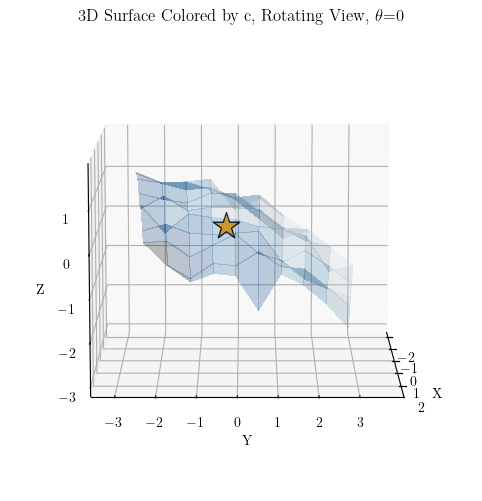

In [180]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata
import matplotlib.cm as cm
import matplotlib.colors as colors
from matplotlib import animation
from IPython.display import HTML

# ------------------------------------------------
# Create some scattered data including a fourth variable 'c'
# ------------------------------------------------

skip = 1

p_idx1 = 2
# p_idx2 = 1
s_idx1 = 6
s_idx2 = 1
s_idx3 = 4


# first panel
# p_idx1 = 0
# s_idx1 = 0
# s_idx2 = 3
# s_idx3 = 4


x = summaries_to_plot[::skip, s_idx1]
y = summaries_to_plot[::skip, s_idx2]
z = summaries_to_plot[::skip, s_idx3]
c = params_to_plot[::skip, p_idx1]
# ------------------------------------------------
# Interpolate to a regular grid
# ------------------------------------------------

# Create a regular grid over the x and y range
grid_x = np.linspace(x.min(), x.max(), 12)
grid_y = np.linspace(y.min(), y.max(), 12)
grid_x, grid_y = np.meshgrid(grid_x, grid_y)

# Interpolate z values on the grid
grid_z = griddata((x, y), z, (grid_x, grid_y), method='linear')

# Interpolate c values on the grid
grid_c = griddata((x, y), c, (grid_x, grid_y), method='linear')

# ------------------------------------------------
# Map the interpolated c values to RGBA colors using a colormap.
# ------------------------------------------------

norm = colors.Normalize(vmin=np.nanmin(grid_c), vmax=np.nanmax(grid_c))
facecolors = cm.Blues_r(norm(grid_c))

# ------------------------------------------------
# Create the surface plot
# ------------------------------------------------

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Generate the surface plot. Note that when using facecolors,
# the z-order is determined by the grid.
surf = ax.plot_surface(
    grid_x, grid_y, grid_z,
    facecolors=facecolors,
    rstride=1, cstride=1,
    linewidth=0, antialiased=False,
    alpha=0.25
)

# Add a colorbar corresponding to the fourth variable, c.
mappable = cm.ScalarMappable(norm=norm, cmap='Blues_r')
mappable.set_array(grid_c)
#cbar = fig.colorbar(mappable, shrink=0.5, aspect=10)
#cbar.set_label('c value')


_ =  ax.scatter(target_summaries[:, s_idx1], target_summaries[:, s_idx2], \
                target_summaries[:, s_idx3], facecolor='orange', \
                edgecolor='k',
                marker='*', s=400, zorder=1000000)



# scatter = ax.scatter(x, y, z, c=c, cmap=cmap_, s=1.5, alpha=0.45)


# ax.scatter(x, y, z, color='r', marker='o', s=10, label='Data Points')

# Set labels and title
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title("3D Surface Colored by c, Rotating View")

# ------------------------------------------------
# Create the animation: update the view angle (azimuth) in 15° increments.
# ------------------------------------------------

def update(frame):
    # For example: fix elevation at 30° and vary azimuth.
    elev = 10 # 30 
    azim = frame * 15  # Increase azim in steps of 15.
    ax.view_init(elev=elev, azim=azim, roll=0)
    ax.set_title(r"3D Surface Colored by c, Rotating View, $\theta$=%d"%(azim))
    return fig,

# Determine the total number of frames (one full rotation: 360 degrees)
num_frames = int(360 / 15)

ani = animation.FuncAnimation(fig, update, frames=num_frames, interval=500, blit=False)

# To display the animation in a Jupyter Notebook as an HTML5 video:
HTML(ani.to_html5_video())

In [ ]:
param_labels = [r'$\Omega_m$', r'$S_8$', r'$w$']

clrs = ['#9ccba3', '#7bb78d', '#60a37d', '#498d6f', '#377863', '#296357', '#1f4f4c', '#183e41', '#122e35', '#0e2029']


c = ChainConsumer()

thin = 3
upto = 2


start = 0

for j in range(4):
    df = pd.DataFrame(target_blind_singles[j][start::thin, :upto], columns=param_labels[:upto])
    c.add_chain(Chain(samples=df, name="NDE %d"%(j), plot_cloud=False, kde=False, color=clrs[j+2]))


c.add_truth(Truth(location={param_labels[0]: 0.3, 
                            param_labels[1]: 0.8, 
                           }))
fig = c.plotter.plot(figsize=(3.41 , 3.41))


plt.savefig("./paper/plots/blinded_single_ndes.pdf", dpi=400)

plt.show()

In [ ]:
#colors = ['#003F5C', '#BC5090', '#FF6361', '#FFA600']
# colors = [ '#3c77e4', '#9D3B6C','#FFA600' , '#19123C', '#3c77e4']

colors = [ 'gray', 
          # '#36454F' , 
          "#818589",
          # '#183e41',
           '#377863',
          # 'k' , 
          # '#3c77e4',
          '#19123C', '#3c77e4']


colors = [ 'gray', 
          "#818589",
           "#3c77e4",
          # '#183e41',
          # '#377863',
          # 'k' , 
          # '#3c77e4',
          '#19123C', '#3c77e4']


prior_om = [0.15, 0.49]
prior_s8 = [0.5, 1.]
prior_w = [-1, -0.33]
prior_IA = [-3, 3.]

n_burn2d = 0

chain_cosmic_shear = './results/desy3_shear_wcdmnu_hyperrank_noSR_2.txt'
uu = np.genfromtxt(chain_cosmic_shear, names=True)
mask = uu['cosmological_parametersomega_m'] > 0.1

label_marco = '2nd+3rd mom.+ST+WPH'
label_betti = r'2nd mom.+Betti'
label_cs = r'Cosmic Shear $\xi_{\pm}$'

# Plot settings
param_limits_plot = {
        'Om': (0.15, 0.49),
        's8': (0.715, 0.925),
        #'s8': (0.5, 1.2),
        'w': (-1, -0.33),
        'IA': (-2, 2)
    }



def reweight(p, mu, sigma):
    likelihood_gaussian = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((p - mu) / sigma)**2)
    likelihood_flat = 1.0  # Flat prior
    weight = likelihood_gaussian / likelihood_flat
    return weight

w1 = reweight(uu['cosmological_parametersh0'], 0.7022, 0.0245)
#w2 = reweight(uu['cosmological_parametersomega_b'], 0.9649, 0.0063)  
w2 = reweight(uu['cosmological_parametersn_s'], 0.9649, 0.0063)  
w3 = reweight((uu['cosmological_parametersomega_b'])*uu['cosmological_parametersh0']**2, 0.02237, 0.00015)  
#w3 = reweight(uu['cosmological_parametersomega_b'], 0.04553, 0.00320)  

names = ['Om', 's8', 'w']
labels = [r'\Omega_{\rm m}', 'S_8', 'w']
ranges = {'Om': prior_om, 's8': prior_s8, 'w': prior_w}

cs = MCSamples(samples=np.c_[uu['cosmological_parametersomega_m'][mask],
                            (uu['COSMOLOGICAL_PARAMETERSSIGMA_8']*np.sqrt(uu['cosmological_parametersomega_m']/0.3))[mask],
                            uu['cosmological_parametersw'][mask]],
               labels =labels,
               label=label_cs,
               weights=((uu['weight']*w1*w2*w3)[mask]), 
               ranges=ranges,
               names=names)


samples_marco = MCSamples(samples=[marco['Om'], marco['S8'], marco['w']],
                    names=names,
                    labels=labels,
                    label=label_marco,
                    settings={'mult_bias_correction_order': 1,
                              'smooth_scale_2D': 0.4,
                              'smooth_scale_1D': 0.2},
                    ranges=ranges)


samples_niall = MCSamples(samples=[niall[:, burnin_niall:,0].flatten(),
                                   niall[:, burnin_niall:,1].flatten(), 
                                   niall[:, burnin_niall:,2].flatten(), 
                                  ],
                     names=['Om', 's8','w'],
                     labels=labels,
                    label='$C_\ell+$CNN (Jeffrey et al)',
                    settings={'mult_bias_correction_order': 1,
                             'smooth_scale_2D': 0.4,
                             'smooth_scale_1D': 0.2},
                    ranges=ranges)


samples_niall_dummy = MCSamples(samples=[niall[:, burnin_niall:,0].flatten(),
                                   niall[:, burnin_niall:,1].flatten(), 
                                   niall[:, burnin_niall:,2].flatten(), 
                                  ],
                     names=['Om', 's8','w'],
                     labels=labels,
                    label=" ",
                    settings={'mult_bias_correction_order': 1,
                             'smooth_scale_2D': 0.4,
                             'smooth_scale_1D': 0.2},
                    ranges=ranges)

samples_hybrid = MCSamples(samples=[hybrid[burnin_niall:,:,0].flatten(),
                                    hybrid[burnin_niall:,:,1].flatten(), 
                                    hybrid[burnin_niall:,:,2].flatten()],
                     names=['Om', 's8','w'],
                     labels=labels,
                    label='$C_\ell+$CNN hybrid statistics (this work)',
                    settings={'mult_bias_correction_order': 1,
                              'smooth_scale_2D': 0.4,
                              'smooth_scale_1D': 0.2},
                    ranges=ranges)




# Configure plot aesthetics
g = plots.get_subplot_plotter(width_inch=5)


# Print figure of merit 
print(1./np.sqrt(np.linalg.det(cs.cov())))
# print(1./np.sqrt(np.linalg.det(samples_betti.cov())))
print(1./np.sqrt(np.linalg.det(samples_marco.cov())))
print(1./np.sqrt(np.linalg.det(samples_niall.cov())))

print(1./np.sqrt(np.linalg.det(samples_hybrid.cov())))
      

print("improvment over DES lensing: ", \
      (1./np.sqrt(np.linalg.det(samples_hybrid.cov()))) / (1./np.sqrt(np.linalg.det(cs.cov())))
     )

print("improvment over Marco: ", \
      (1./np.sqrt(np.linalg.det(samples_hybrid.cov()))) / (1./np.sqrt(np.linalg.det(samples_marco.cov())))
     )

print("improvment over Niall: ", \
      (1./np.sqrt(np.linalg.det(samples_hybrid.cov()))) / (1./np.sqrt(np.linalg.det(samples_niall.cov())))
     )

g.settings.alpha_filled_add = 0.9
g.settings.alpha_factor_contour_lines = 0.4

# Plot the triangle plot with customized settings
g.triangle_plot([cs, samples_niall, samples_hybrid], ['Om', 's8', 'w'], 
                legend_loc='upper right',legend_title='DES Y3', 
                filled=[False, True, True, False, False],
                contour_ls = ['--','dashdot', '-', 'dashdot','-'],  
                contour_lws=[1.5,1,1,1],
                contour_colors= colors, param_limits=param_limits_plot,
                title_limit=None, diag1d_kwargs=dict(normalized=True))



        
# Save the figure
# plt.savefig('./paper/plots/' + 'DESY3_hybrid_w.png', dpi=500)
# plt.savefig('./paper/plots/' + 'DESY3_hybrid_w.pdf', dpi=500)


In [147]:
samples_hybrid.getLatex(), samples_niall.getLatex(), cs.getLatex()

((['\\Omega_{\\rm m}', 'S_8', 'w'],
  ['0.326^{+0.020}_{-0.026}', '0.802\\pm 0.017', '-0.844^{+0.065}_{-0.12}']),
 (['\\Omega_{\\rm m}', 'S_8', 'w'],
  ['0.283^{+0.020}_{-0.027}', '0.804^{+0.025}_{-0.017}', '< -0.804']),
 (['\\Omega_{\\rm m}', 'S_8', 'w'],
  ['0.303^{+0.040}_{-0.051}', '0.813^{+0.020}_{-0.029}', '< -0.707']))

In [ ]:
# spit out mode, 

In [95]:
p.s8

array([0.82917136, 0.77476496, 0.79716223, ..., 0.8081386 , 0.7862251 ,
       0.8160375 ], dtype=float32)

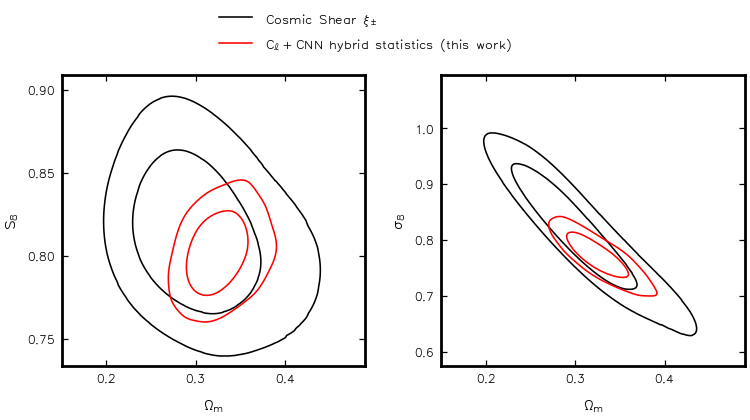

In [149]:
# Add and plot a new derived parameter
# getParms gets p so that p.x0, p.x1.. are numpy vectors of sample values
# For individual parameters you can also just do samples['x0'] etc.

for c in [samples_hybrid, cs, samples_niall]:

    p = c.getParams()
    assert np.all(p.Om == c["Om"])
    c.addDerived(p.s8 / ((p.Om / 0.3) ** 0.5), name="sigma_8", label="\sigma_8")


g = plots.get_subplot_plotter(subplot_size=4)
g.plots_2d([cs, samples_hybrid], "Om", ["s8", "sigma_8"], nx=2);

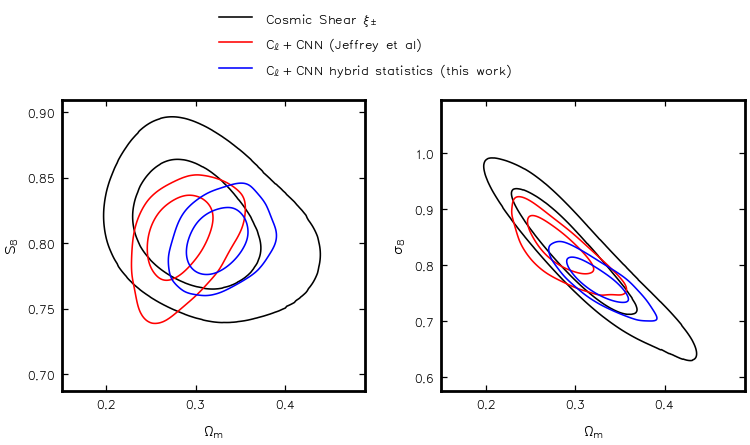

In [150]:
g = plots.get_subplot_plotter(subplot_size=4)
g.plots_2d([cs, samples_niall, samples_hybrid], "Om", ["s8", "sigma_8"], nx=2);

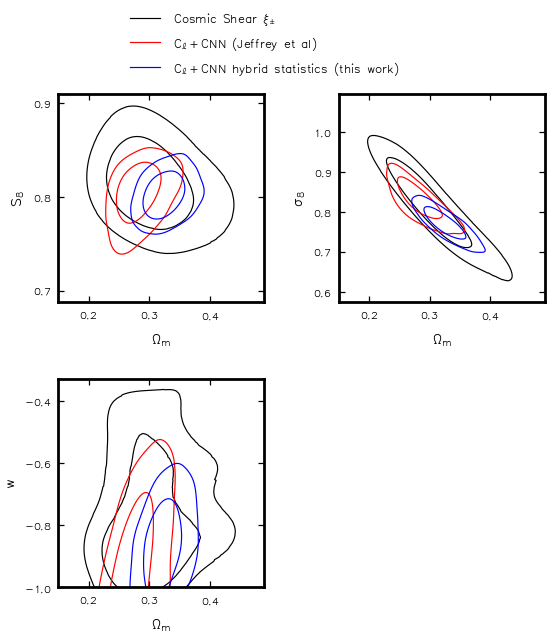

In [151]:
g = plots.get_subplot_plotter(subplot_size=3)
g.plots_2d([cs, samples_niall, samples_hybrid], "Om", ["s8", "sigma_8", "w"], nx=2);

In [10]:
res = print_cosmological_results(cs, name = 'DES Y3 cosmic shear')
res = print_cosmological_results(samples_betti, name = 'Betti + 2nd moment')
res = print_cosmological_results(samples_marco, name = 'Marco')

DES Y3 cosmic shear &0.813$^{+0.032}_{-0.022}$ &0.303$^{+0.040}_{-0.051}$ $& < -0.77$  &0.34$^{+0.28}_{-0.25}$ & 40368 \\
Betti + 2nd moment &0.821$^{+0.018}_{-0.018}$ &0.304$^{+0.037}_{-0.037}$ $& < -0.81$  &0.64$^{+0.35}_{-0.35}$ & 42347 \\
Marco &0.817$^{+0.021}_{-0.022}$ &0.273$^{+0.029}_{-0.029}$ $& < -0.78$  &0.37$^{+0.30}_{-0.29}$ & 56607 \\
